# Building Altimetric Rating Curves (ARC) from satellite-derived river water surface elevation (WSE; Hydroweb.next, HydroSat, DAHITI) and reference discharge (Q; in situ or model simulations like MeanDRS, GRADES-HydroDL)

## Adaptation in Python of the non parametric stochastic quantile mapping (NPQM) method from Elmi et al., 2021

_Notebook Authors: Arnaud Cerbelaud, NASA Jet Propulsion Laboratory - California Institute of Technology (April 2024 - April 2025)._ All rights reserved.

In [1]:
#!/usr/bin/env python3
# **********************************************************************************************************************************
# ARC_fitting_NPQM.ipynb
# **********************************************************************************************************************************

# Purpose:
# Building altimetric rating curves using non parametric quantile mapping
# Author:
# Arnaud Cerbelaud, 2026

In [2]:
# **********************************************************************************************************************************
# Import Python modules
# **********************************************************************************************************************************

import glob
import os
import xarray as xr
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import math
from scipy.stats import norm
from scipy.interpolate import interp1d

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# **********************************************************************************************************************************
# Declaration of variables
# **********************************************************************************************************************************
# 1 - data_folder
# 2 - discharge_files_folder
# 3 - altimetric_wse_files_folder

##############################################################################
# 1 - data_folder
##############################################################################
data_folder = ""


##############################################################################
# 2 - discharge_files_folder
##############################################################################
# Define reference discharge files folder
discharge_files_folder = data_folder + "xxx/"

### Label for reference discharge in plots (in situ or model simulations, such as, e.g., GRFR, GRADES-HYDRODL, or MeanDRS)
type_discharge = ""

### If getting reference discharge from model simulations: choose PFAF region to download from the underlying hydrography (e.g., MERIT Basins)
region = [,,,,]
region_order = {r: i for i, r in enumerate(region)}
# This is the list of meandrs discharge files (i.e., where MeanDRS provides corrected simulations from gauges).
# The other regions were NOT corrected because no long-term continuous gauge records were available (e.g. Indonesia, Nile) -> open-loop simulation.
list_pfaf_meandrs = {'1': ['12','13','14'],
                     '2': ['21','22','23','24','25','26','27','29'],
                     '3': ['31','32','33','34','35'],
                     '4': ['41','45'],
                     '5': ['56','57'],
                     '6': ['61','62','63','64','65','66'],
                     '7': ['71','72','73','74','75','77','78'],
                     '8': ['81','82','83']
                    }

### Actual files
discharge_files = sorted(
    (f for f in glob.iglob(discharge_files_folder + '*.nc4')
     if any(f"_{r}_" in f for r in region)),
    key=lambda f: region_order[next(r for r in region if f"_{r}_" in f)]
)

##############################################################################
# 3 - altimetric_wse_files_folder
##############################################################################
# Choose WSE data source (hydroweb, hydrosat, DAHITI...)
# See ARC_preprocess_Hydroweb.py for example details on the file format
altimetric_wse_files_folder = data_folder + 'yyy/'

# Which columns correspond to the actual WSE time series in the altimetric_wse_files
start_wse = 44    # for hydroweb.next preprocessed files, the first 43 columns are VS attributes.
end_wse = -2      # for hydroweb.next preprocessed files, the last two columns are not actual data
# Column labels that give the name for each virtual station (VS)
# the ID of the VS
# the ID of the discharge location that the VS was snapped to
# the altimeter used in the altimetric_wse_files,
# the name of the river on which the VS is,
# and the width of the river at that VS
ID_VS  = 'ID'
ID_Q   = 'COMID'
satvar = 'MISSION(S)-TRACK(S)'
river_name_db = 'RIVER'
width_db = 'APPROX. WIDTH OF REACH (m)'

In [4]:
# **********************************************************************************************************************************
# Static variables, parameters
# **********************************************************************************************************************************

##############

# If you want to provide a list of VS IDs you want to calibrate RCs on, otherwise ID_list = ''
ID_list = [,,,]

# Which altimeter do I want to work on? Leave sat_1 empty if working with all satellites available
sat_1 = ''  #e.g., 'S3A' 'S3B' 'S6A' 'ENV' 'J1' J2' 'J3' 'ERS' 'SRL'
sat_2 = ''
sat_3 = ''

##############

# Optimize RC on log streamflow (=1, 0 otherwise)
log = 0

# Define datetime range: Jason-3 and Sentinel-3A data start in 2016, S3B in 2018, S6A in 2021
start_date = '1980-01-01'
end_date = '2024-09-30'

# Plot visualization
do_plot_q_WSE = 1
do_plot_QQ = 1
do_plot_qfromWSE = 1

In [5]:
# **********************************************************************************************************************************
# Functions
# **********************************************************************************************************************************

#####
# ARC-related
#####

# Function to remove outliers in WSE
def remove_outliers(series, threshold=2):
    # Removes outliers
    mean = series.mean()
    std_dev = series.std()
    z_scores = (series - mean) / std_dev
    filtered_series = series[abs(z_scores) < threshold]
    return filtered_series

def remove_uncertain_wse(series, series_u, threshold=1):
    std_dev = series.std()
    return series[series_u < threshold*std_dev]

# Function to find the mean of nearest values within a specified window
def mean_nearest_values(ts, date, window):
    start_date = date - pd.Timedelta(days=window)
    end_date = date + pd.Timedelta(days=window)
    nearest_values = ts.loc[start_date:end_date]
    return nearest_values.mean()

# Power-law fitting
# Define the power law function
def power_law(H, Z0, a, b):
    return a*(H-Z0)**b

def power_law_log(H, Z0, a, b):
    return np.log(a)+b*np.log(H-Z0)


#####
# Hydrological metrics
#####

### Nash-Sutcliffe Efficiency
def lognse(observed, simulated):
    """
    Log Nash-Sutcliffe Efficiency (NSE)
    """
    mean_observed = np.mean(np.log(observed))
    numerator = np.sum((np.log(observed) - np.log(simulated.astype(float))) ** 2)
    denominator = np.sum((np.log(observed) - np.log(mean_observed)) ** 2)
    nse_value = 1 - (numerator / denominator)
    return nse_value

def nse(observed, simulated):
    """
    Nash-Sutcliffe Efficiency (NSE)
    """
    mean_observed = np.mean(observed)
    numerator = np.sum((observed - simulated) ** 2)
    denominator = np.sum((observed - mean_observed) ** 2)
    nse_value = 1 - (numerator / denominator)
    return nse_value

### Kling-Gupta Efficiency and its three components
def correlation(observed, simulated):
    """
    Pearson correlation coefficient
    """
    mean_observed = np.mean(observed)
    mean_simulated = np.mean(simulated)
    numerator = np.sum((observed - mean_observed) * (simulated - mean_simulated))
    denominator = np.sqrt(np.sum((observed - mean_observed) ** 2) * np.sum((simulated - mean_simulated) ** 2))
    correlation_value = numerator / denominator
    return correlation_value

def nbias(observed, simulated):
    """
    Normalized Bias (NBIAS) by mean of obs
    """
    mean_observed = np.mean(observed)
    nbias_value = np.mean(simulated - observed) / mean_observed
    return np.abs(nbias_value)

def nstderr(observed, simulated):
    """
    Normalized Standard Error (NStdErr)
    """
    if np.std(observed) == 0:
        nstderr_value = np.nan  # or some other default value
    else:
        nstderr_value = (np.std(simulated) - np.std(observed)) / np.std(observed)
    return np.abs(nstderr_value)

def kge(observed, simulated):
    """
    Kling-Gupta Efficiency (KGE)
    """
    mean_observed  = np.mean(observed)
    mean_simulated = np.mean(simulated)
    std_observed   = np.std(observed)
    std_simulated  = np.std(simulated)

    try:
        correlation_value = correlation(observed, simulated)
    except:
        correlation_value = observed.corr(simulated)

    if std_observed == 0:
        kge_value = np.nan  # or some other default value
    else:
        kge_value = 1 - np.sqrt((np.square(1 - correlation_value) + 
                                 np.square((mean_simulated / mean_observed) - 1) + 
                                 np.square((std_simulated / std_observed) - 1)))
    return kge_value

### Other metrics
def rmse(observed, simulated):
    """
    Root Mean Squared Error (RMSE)
    """
    rmse_value = np.sqrt(np.mean((observed - simulated) ** 2))
    return rmse_value

def nrmse(observed, simulated):
    """
    Normalized Root Mean Squared Error (NRMSE) by mean of obs
    """
    nrmse_value = rmse(observed, simulated) / np.mean(observed)
    return nrmse_value

def prmse(observed, simulated):
    """
    Percentage Root Mean Squared Error (PRMSE) by RMS of obs
    """
    prmse_value = rmse(observed, simulated) / np.sqrt(np.mean(observed**2))
    return prmse_value

def rrmse(observed, simulated):
    """
    Relative Root Mean Squared Error (RRMSE) by max-min of obs
    """
    rrmse_value = rmse(observed, simulated) / (np.max(observed)-np.min(observed))
    return rrmse_value

def pbias(observed, simulated):
    """
    Percentage Bias (PBIAS) by RMS of obs
    """
    RMS_observed = np.sqrt(np.mean(observed**2))
    rbias_value = np.mean(simulated - observed) / RMS_observed
    return rbias_value

def rbias(observed, simulated):
    """
    Relative Bias (RBIAS) by max-min of obs
    """
    range_observed = np.max(observed)-np.min(observed)
    rbias_value = np.mean(simulated - observed) / range_observed
    return rbias_value

In [6]:
# **********************************************************************************************************************************
# Non parametric stochastic quantile mapping discharge algorithm
# Some of the Matlab code was CHANGED, and some lines were ADDED compared to Elmi, Tourian, et al. (2021)
# **********************************************************************************************************************************

# **********************************************************************************************************************************
# Parameters
# **********************************************************************************************************************************

disch_uncer = 0.25
wse_uncer   = 0.25
num_sample = 101
iq_range = 0.99  # set between 0.51 and 0.99, realistically between 0.75 and 0.99. the higher the larger the output uncertainty
N_sigma = 3
N_sigma_strict = N_sigma

# **********************************************************************************************************************************
# Code
# **********************************************************************************************************************************


def quantile_mapping(discharge, discharge_u, wse, wse_u):

    # Determine coinciding measurements in time
    a, b, c = np.intersect1d(wse.index, discharge.index, return_indices=True)
    # wse[b] and discharge[c] are coinciding measurements (on the same dates)
    if a.size > 0:
        sim_data_org = np.column_stack((a, wse[b], discharge[c]))  # 1) date 2) wse 3) discharge

    # Initializing the datasets for Monte Carlo (MC) realizations of WSE and discharge
    discharge_mont_init = np.column_stack((discharge.index.to_list(),
                                           discharge,
                                           discharge_u,
                                           discharge))
    wse_mont_init       = np.column_stack((wse.index.to_list(),
                                           wse,
                                           wse_u,
                                           wse))

    # Generating MC realizations
    # Initializing num_sample series of length identical to each WSE and discharge series
    discharge_mont = np.hstack((discharge_mont_init, np.zeros((discharge_mont_init.shape[0], num_sample))))
    wse_mont       = np.hstack((wse_mont_init, np.zeros((wse_mont_init.shape[0], num_sample))))
    
    # For each date, generate a random perturbation, with a constraint not to go below the min WSE or discharge
    for i in range(len(discharge_mont)):
        discharge_mont[i,4:] = np.maximum(np.min(discharge_mont[:, 1]),norm.rvs(loc=discharge_mont[i, 1], scale = 2*discharge_mont[i, 2], size=num_sample))
    for i in range(len(wse_mont)):
        wse_mont[i,4:]       = np.maximum(np.min(wse_mont[:, 1]), norm.rvs(loc=wse_mont[i, 1], scale = wse_mont[i, 2], size=num_sample))
        
    ### ADDED: We store the max value taken by any discharge in MC realizations so that later we don't extrapolate too much
    # in odd cases of quantile mapping (it could cause discharge values to explode)
    max_value_for_Q_from_WSE = np.full(len(wse), np.max(discharge_mont[:,4:]))

    # Calculate the quantile tables of both WSE and discharge
    p = np.arange(0, 1.01, 0.01)
    quant_dis       = np.column_stack((p, np.quantile(discharge_mont[:, 1], p)))   # discharge_mont[:, 1] is the real reference discharge
    #quant_dis       = quant_dis[np.argsort(quant_dis[:, 1])]
    #quant_dis       = np.column_stack((p, quant_dis[:, 1]))

    quant_wse       = np.column_stack((p, np.quantile(wse_mont[:, 1], p)))      # wse_mont[:, 1] is the real wse
    #quant_wse       = quant_wse[np.argsort(quant_wse[:, 1])]
    #quant_wse       = np.column_stack((p, quant_wse[:, 1]))

    # Reference quantiles side-by-side = ref quantile table
    quant_table_org = np.column_stack((quant_wse[:, 1], quant_dis[:, 1]))

    # Generate each combination of WSE-discharge MC quantile tables = quantile lookup tables
    quant_look = np.zeros((len(p), num_sample*num_sample, 2))     # [:,:,0] is for WSE; [:,:,1] is for discharge
    quant_dis  = np.array([np.append(row, 0) for row in quant_dis])  # adding one other column
    quant_wse  = np.array([np.append(row, [0] * num_sample) for row in quant_wse]) # adding num_sample other columns
    # Looping through MC realizations
    for n in range(num_sample):
        # Adding the #n MC realization discharge quantiles, creating num_sample blocks of 101 rows * num_sample columns 
        quant_dis[:,2] = np.column_stack((p, np.quantile(discharge_mont[:, 4+n], p)))[:, 1]
        quant_look[:, (num_sample*n):num_sample*(n+1), 1] = np.tile(quant_dis[:, 2], (num_sample, 1)).T
        if n == 0:   # only doing it once, storing everywhere
            for m in range(num_sample):
                quant_wse[:,2+m] = np.column_stack((p, np.quantile(wse_mont[:, 4+m], p)))[:, 1]
            for q in range(num_sample):
                quant_look[:, (num_sample*q):num_sample*(q+1), 0] = quant_wse[:, 2:]
    # Example for quant_look for num_sample = 3
    #                        col:    0         1         2         3         4         5         6         7         8
    #                               ------------------------------------------------------------------------------------
    # quant_look[:,0:8,0]   WSE |  WSE_MC0  WSE_MC1   WSE_MC2   WSE_MC0   WSE_MC1   WSE_MC2   WSE_MC0   WSE_MC1   WSE_MC2
    # quant_look[:,0:8,1]   Q   |   Q_MC0    Q_MC0     Q_MC0     Q_MC1     Q_MC1     Q_MC1     Q_MC2     Q_MC2     Q_MC2
    
    
    # Taking the mean quantile function
    quant_look_mean     = np.column_stack((np.mean(quant_look[:, :, 0], axis=1), np.mean(quant_look[:, :, 1], axis=1)))
    
    # Calculating a range in quantile functions = uncertainty
    ### CHANGED: The std deviation provides very small uncertainties after a few iteration steps when disch_uncer and
    ###          wse_uncer are updated. Here, we rather take interquartile range, which can be set to the desired level
    #quant_look_standard = np.column_stack((np.std( quant_look[:, :, 0], axis=1), np.std(quant_look[:, :, 1], axis=1)))
    quant_look_standard = np.column_stack((np.quantile( quant_look[:, :, 0], iq_range, axis=1 ) - np.quantile( quant_look[:, :, 0], 1-iq_range, axis=1 ), \
                                           np.quantile( quant_look[:, :, 1], iq_range, axis=1 ) - np.quantile( quant_look[:, :, 1], 1-iq_range, axis=1 )))
    
    #### Converting WSE to Q from the mean MC quantile mapping table
    # Note/reminder: quant_look_mean[:, 0] is the mean quantiles of WSE MC realizations
    #                quant_look_mean[:, 1] is the mean quantiles of Q MC realizations
    
    # discharge_recunst_mean      will be the discharge series obtained from quantile mapping of the WSE time series in the average scenario (e.g., Jan. 3: Q_fromWSE = 10 m3/s, Jan. 30: 47 m3/s)
    # discharge_recunst_mean_perc will be the quantiles each data point in the WSE time series belong to (e.g., Jan. 3: 4th quantile, Jan. 30: 18th quantile)
    discharge_recunst_mean       = interp1d(quant_look_mean[:, 0], quant_look_mean[:, 1], kind='linear', fill_value='extrapolate')(wse.to_list())
    discharge_recunst_mean_perct = np.fix(interp1d(quant_look_mean[:, 0], np.arange(0, 101), kind='linear', fill_value='extrapolate')(wse.to_list()))
    discharge_recunst_mean_perct[discharge_recunst_mean_perct < 0]   = 0
    discharge_recunst_mean_perct[discharge_recunst_mean_perct > 100] = 100
    discharge_recunst_mean_perct = [0 if np.isnan(val) else val for val in discharge_recunst_mean_perct]

    # wse_recunst_mean      will be the wse series obtained from inverse quantile mapping of the discharge time series in the average scenario
    # wse_recunst_mean_perc will be the quantiles each data point in the discharge time series belong to
    wse_recunst_mean       = interp1d(quant_look_mean[:, 1], quant_look_mean[:, 0], kind='linear', fill_value='extrapolate')(discharge.to_list())
    wse_recunst_mean_perct = np.fix(interp1d(quant_look_mean[:, 1], np.arange(0, 101), kind='linear', fill_value='extrapolate')(discharge.to_list()))
    wse_recunst_mean_perct[wse_recunst_mean_perct < 0]   = 0
    wse_recunst_mean_perct[wse_recunst_mean_perct > 100] = 100
    wse_recunst_mean_perct = [0 if np.isnan(val) else val for val in wse_recunst_mean_perct]

    ###
    # Now we map and produce the discharge/inverse WSE in every possibility from one WSE MC simulation to a Q MC simulation and vice versa.
    # The goal being to estimate the deviation from the average scenario (residuals) ON THE TIME SERIES domain, as opposed to on the quantile series domain in quant_look_standard.
    ###
    # discharge_recunst will hold all the possibilities of discharge from quantile mapping of the WSE time series with simulated Q in all MC scenario
    discharge_recunst       = []
    discharge_recunst_perct = []

    for i in range(quant_look.shape[1]):
        quant_look_temp = quant_look[:, i, :]
        # First we deal with the list of percentiles: if it is non strictly monotonous (duplicates) we need to reprocess it
        if len(np.unique(quant_look_temp[:, 0])) < 101:      # just making sure
            unique_indices = np.unique(quant_look_temp[:, 0], return_index=True)[1]   # returning the list of unique percentiles, making sure we do not have duplicates in list of WSE percentiles
            missing_indices = np.setdiff1d(np.arange(101), unique_indices)
            # If there are non-unique percentiles, we reassign them to the mean of the percentile before and after
            for k in missing_indices:
                try:
                    quant_look_temp[k, 0] = (quant_look_temp[k-1, 0] + quant_look_temp[k+1, 0]) / 2
                except:
                    quant_look_temp[k, 0] = quant_look_temp[k-1, 0]
        # Doing the same with discharge
        if len(np.unique(quant_look_temp[:, 1])) < 101:      # just making sure
            unique_indices = np.unique(quant_look_temp[:, 1], return_index=True)[1]
            missing_indices = np.setdiff1d(np.arange(101), unique_indices)
            for k in missing_indices:
                try:
                    quant_look_temp[k, 1] = (quant_look_temp[k-1, 1] + quant_look_temp[k+1, 1]) / 2
                except:
                    quant_look_temp[k, 1] = quant_look_temp[k-1, 1]

        # Then we convert all MC time series realizations of WSE to Q from the MC quantile mapping table "quant_look_temp".
        # IMPORTANT CHANGE: In odd cases of quantile mapping where the highest quantile value resulting from the MC
        # realization of WSE is very low and the discharge high quantiles are on the contrary very high, the linear
        # extrapolation below can result in very high discharge produced from WSE by the algorithm, we cap it here
        # with the highest discharge value produced in all the MC realizations.
        discharge_recunst.append(       np.minimum( interp1d(quant_look_temp[:, 0], quant_look_temp[:, 1], kind='linear', fill_value='extrapolate')(wse.to_list()), max_value_for_Q_from_WSE) )
        discharge_recunst_perct.append( np.fix(interp1d(quant_look_temp[:, 0], np.arange(0, 101), kind='linear', fill_value='extrapolate')(wse.to_list())) )
        discharge_recunst_perct[i][discharge_recunst_perct[i] < 0]   = 0
        discharge_recunst_perct[i][discharge_recunst_perct[i] > 100] = 100
        discharge_recunst_perct[i] = [0 if np.isnan(val) else val for val in discharge_recunst_perct[i]]
        
    ### Range of the quantile-mapped Q_from_WSE in all MC simulations
    #discharge_std = np.nanstd(discharge_recunst, axis=0)
    discharge_std = np.quantile(discharge_recunst, iq_range, axis=0) - np.quantile(discharge_recunst, 1-iq_range, axis=0)

    
    ### Uncertainty interval in the MC simulations
    order = [np.argsort(arr) for arr in discharge_recunst_perct]  # Generate sorting orders for each array
    # Reorder each array in the list according to its corresponding order
    discharge_recunst_reordered = [
        np.take_along_axis(arr, idx_order, axis=0) for arr, idx_order in zip(discharge_recunst, order)
    ]
    min_discharge_recunst = np.min(np.maximum(discharge_recunst_reordered, 0), axis=0)
    max_discharge_recunst = np.max(discharge_recunst_reordered, axis=0)

    ### Residuals based on quantiles in the average MC scenario vs real quantiles
    wse_prob = np.column_stack((wse_recunst_mean_perct, quant_wse[np.round(wse_recunst_mean_perct).astype(int), 1], wse_recunst_mean))
    dis_prob = np.column_stack((discharge_recunst_mean_perct, quant_dis[np.round(discharge_recunst_mean_perct).astype(int), 1], discharge_recunst_mean, discharge_std))

    res_wse = np.sqrt(np.nanmean((wse_prob[:,1]-wse_prob[:,2])**2))
    res_dis = np.sqrt(np.nanmean((dis_prob[:,1]-dis_prob[:,2])**2))

    # Then we calculate using the 3 sigma rule (choose N_sigma = 3 or other) the updated MC perturbations for another run of the algorithm, to ultimately converge
    wse_prob = wse_prob[wse_prob[:, 0].argsort()]
    dis_prob = dis_prob[dis_prob[:, 0].argsort()]
    
    UniW = np.unique(wse_prob[:, 0])
    wse_u_updateperc = []
    for val in UniW:
        indices = np.where(wse_prob[:, 0] == val)[0]
        Res     = np.max(np.abs(wse_prob[indices, 1] - wse_prob[indices, 2]))/N_sigma
        wse_u_updateperc.append([val, Res])
    wse_u_updateperc = np.array(wse_u_updateperc)
    unique_indices = np.unique(quant_wse[:, 1], return_index=True)[1]
    interp_ = interp1d(quant_wse[unique_indices][:, 1], quant_wse[unique_indices][:, 0], kind='linear', fill_value="extrapolate")
    wse_perc = np.fix([0 if np.isnan(val) else val for val in interp_(wse.to_list()) * 100])
    wse_perc[wse_perc == 0] = 1
    interp_2 = interp1d(wse_u_updateperc[:, 0], wse_u_updateperc[:, 1], kind='linear', fill_value="extrapolate")
    # We finally obtain the updated MC perturbations for the real WSE series
    wse_perc_update = np.column_stack((wse_perc, [0 if np.isnan(val) else val for val in interp_2(wse_perc.tolist())]))    

    UniQ = np.unique(dis_prob[:, 0])
    dis_u_updateperc = []
    for val in UniQ:
        indices = np.where(dis_prob[:, 0] == val)[0]
        ### CHANGED: if the distance between the reference discharge and the discharge obtained from WSE, both at the same quantile,
        ###         exceeds the average range of the quantile-mapped Q_from_WSE in all MC simulations, a stricter is be applied
        if np.max(np.abs(dis_prob[indices, 1] - dis_prob[indices, 2])) > np.nanmean(dis_prob[:, 3]):
            Res = np.max(np.abs(dis_prob[indices, 1] - dis_prob[indices, 2]))/(N_sigma_strict)
        else:
            Res = np.max(np.abs(dis_prob[indices, 1] - dis_prob[indices, 2]))/N_sigma
        dis_u_updateperc.append([val, Res])
    dis_u_updateperc = np.array(dis_u_updateperc)
    unique_indices = np.unique(quant_dis[:, 1], return_index=True)[1]
    interp_ = interp1d(quant_dis[unique_indices][:, 1], quant_dis[unique_indices][:, 0], kind='linear', fill_value="extrapolate")
    dis_perc = np.fix(interp_(discharge.to_list()) * 100)
    dis_perc[dis_perc == 0] = 1
    interp_2 = interp1d(dis_u_updateperc[:, 0], dis_u_updateperc[:, 1], kind='linear', fill_value="extrapolate")
    # We finally obtain the updated MC perturbations for the real reference discharge series
    dis_perc_update = np.column_stack((dis_perc, [0 if np.isnan(val) else val for val in interp_2(dis_perc.tolist())]))


    return(quant_table_org, 
           quant_look, quant_look_mean, quant_look_standard,
           discharge_recunst_mean, discharge_std,
           min_discharge_recunst, max_discharge_recunst,
           wse_prob, dis_prob,
           res_wse, res_dis,
           dis_perc_update, wse_perc_update)


In [7]:
# **********************************************************************************************************************************
# Read files
# **********************************************************************************************************************************
print('Reading files')

# Read reference discharge Q files
ds_all = [xr.open_dataset(x, engine='h5netcdf') for x in discharge_files]
ds_sims = xr.concat(ds_all, dim="rivid")

# Read WSE altimetric files
# Contains the translation between the location of the altimetric data (e.g., virtual station, SWORD rivid) and
# the corresponding feature on which reference discharge is given (e.g., closest in situ station, snapped MERIT COMID)
# These are outputs from 'ARC_preprocess_Hydroweb.ipynb'.
alti_loc_data = pd.read_csv(  altimetric_wse_files_folder + '***.csv', index_col=0)  # snapping done in QGIS
# Contains the WSE data from altimetry
wse_data      = pd.read_csv(  altimetric_wse_files_folder + '***.csv', index_col=0)
# Contains the WSE uncertainty data from altimetry
wse_u_data    = pd.read_csv(  altimetric_wse_files_folder + '***.csv', index_col=0)

Reading files


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/xarray/core/concat.py:527: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  common_dims = tuple(pd.unique([d for v in vars for d in v.dims]))
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/818909876.py:16: DtypeWarning: Columns (6007,6008) have mixed types. Specify dtype option on import or set low_memory=False.
  wse_data      = pd.read_csv(  altimetric_wse_files_folder + '_wse_database.csv', index_col=0)
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/818909876.py:18: DtypeWarning: Columns (6007,6008

In [8]:
# **********************************************************************************************************************************
# Linking WSE to the corresponding reference discharge
# **********************************************************************************************************************************

######
# Intersecting the two databases, keeping only the WSE at locations where we
# uploaded reference discharge ("region" variable)
######
wse_data      = wse_data[alti_loc_data[ID_Q].isin(ds_sims.rivid.values)]
wse_u_data    = wse_u_data[alti_loc_data[ID_Q].isin(ds_sims.rivid.values)]
alti_loc_data = alti_loc_data[alti_loc_data[ID_Q].isin(ds_sims.rivid.values)]

In [9]:
# **********************************************************************************************************************************
# Displaying virtual stations in the filtered dataset
# **********************************************************************************************************************************

print("Uploaded discharge data covers: ")
for sat in np.unique([i[:3] for i in alti_loc_data[satvar]]):
    print(sat + " has " + str(len([i for i in alti_loc_data[satvar] if i[:3]==sat])) + " VS")
    
# List of virtual stations

if ID_list != '':
    vs_list = alti_loc_data.index[ alti_loc_data[ID_VS].isin(ID_list) ].tolist()
    print('Code will work on ' + str(len(vs_list)) + ' VS')
else:
    if sat_1 != '':
        vs_list = [i for i in alti_loc_data.index if (sat_1 in alti_loc_data[satvar][i]) or (sat_2 in alti_loc_data[satvar][i]) or (sat_3 in alti_loc_data[satvar][i])]
        print('Code will work on ' + str(len(vs_list)) + ' VS from ' + sat_1 + ', '+ sat_2 + ', and ' + sat_3)
    else:
        vs_list = [i for i in alti_loc_data.index]
        print('Code will work on ' + str(len(vs_list)) + ' VS')


Uploaded discharge data covers: 
J2- has 160 VS
J3- has 27 VS
S3A has 1671 VS
S3B has 1623 VS
S6A has 273 VS
SWO has 768 VS
Code will work on 18 VS


In [10]:
# **********************************************************************************************************************************
# Initializations
# **********************************************************************************************************************************

# If want to work on subset of virtual stations
vs_list = vs_list[:]

######
# Initializing result dataframe
######
# WSE and associated Q quantiles
for var in [f'WSE_{i}' for i in range(0, 101)]:
    alti_loc_data[var] = 0
    alti_loc_data[var] = alti_loc_data[var].astype(float)
for var in [f'Q_{i}' for i in range(0, 101)]:
    alti_loc_data[var] = 0
    alti_loc_data[var] = alti_loc_data[var].astype(float)
# WSE and associated Q quantiles from mean Monte Carlo simulations in NPQM
for var in [f'WSE_meanMC_{i}' for i in range(0, 101)]:
    alti_loc_data[var] = 0
    alti_loc_data[var] = alti_loc_data[var].astype(float)
for var in [f'Q_meanMC_{i}' for i in range(0, 101)]:
    alti_loc_data[var] = 0
    alti_loc_data[var] = alti_loc_data[var].astype(float)
for var in [f'Q_u_meanMC_{i}' for i in range(0, 101)]:
    alti_loc_data[var] = 0
    alti_loc_data[var] = alti_loc_data[var].astype(float)
# Metrics for ARC performance
for var in ['KGE', 'Corr', 'NBIAS', 'NSTDERR', 'NRMSE', 'PRMSE', 'RRMSE']:
    alti_loc_data[var] = 0
    alti_loc_data[var] = alti_loc_data[var].astype(float)

######
# Filtering reference discharge on locations where virtual stations are
######
rivid_list = []
for vs in vs_list:
    rivid_list.append(alti_loc_data.loc[vs,ID_Q])
ds_sims = ds_sims.where(ds_sims.rivid.isin(rivid_list), drop=True)

######
# Initializing result metrics dataframe
######
nse_list = []
kge_list = []
corr_list = []
nstderr_list = []
nbias_list = []
nrmse_list = []
prmse_list = []
rrmse_list = []

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/3392596826.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  alti_loc_data[var] = 0
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/3392596826.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  alti_loc_data[var] = 0
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/3392596826.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

726 ############################


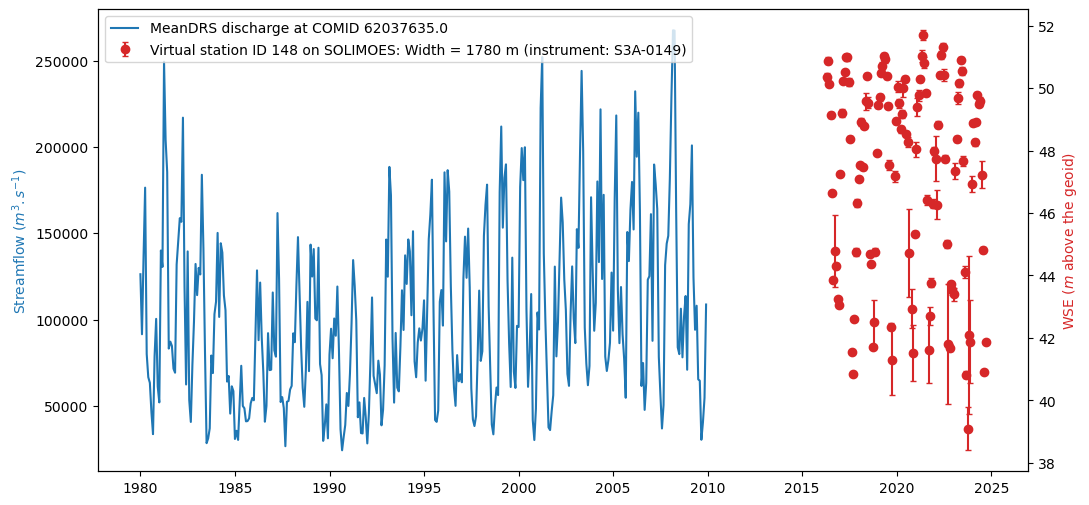

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


2
3
4
5


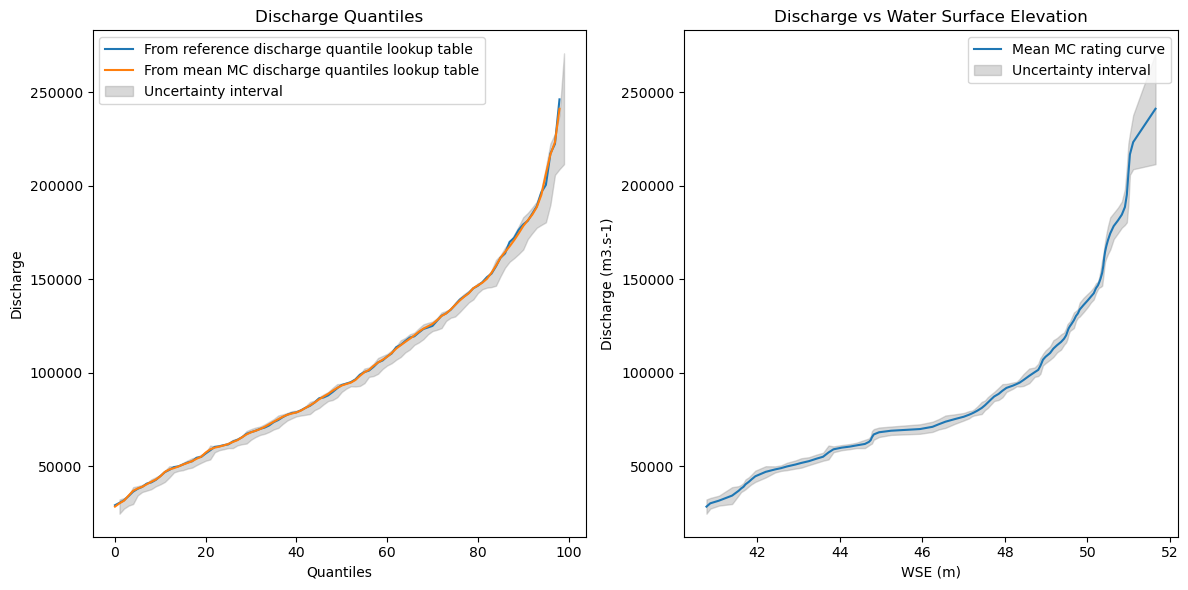

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.65 ; Corr: 0.86 ; NBIAS: 0.02 ; NSTDERR: 0.32 ; NRMSE: 0.23 ; PRMSE: 0.21 ; RRMSE: 0.22


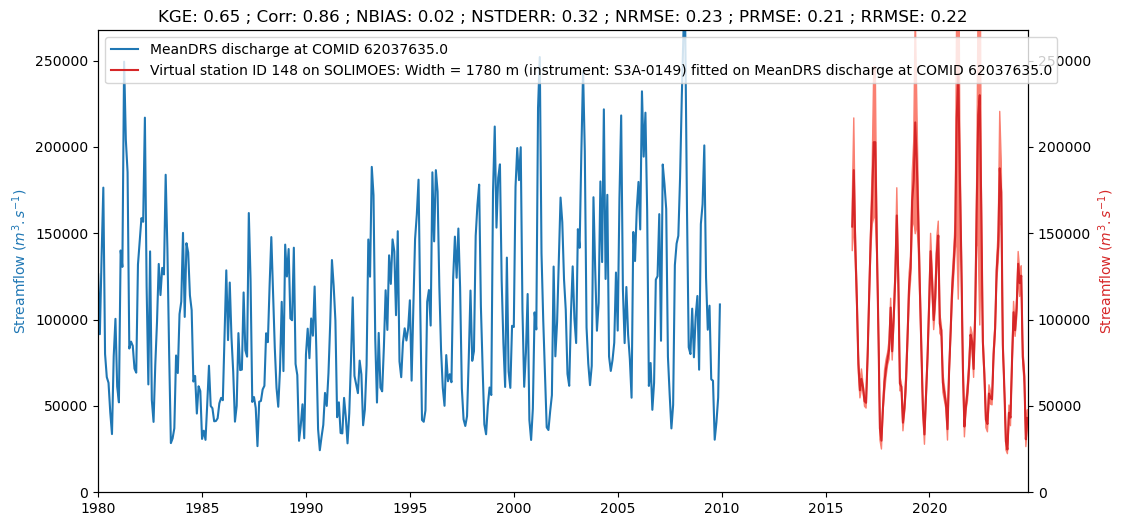

813 ############################


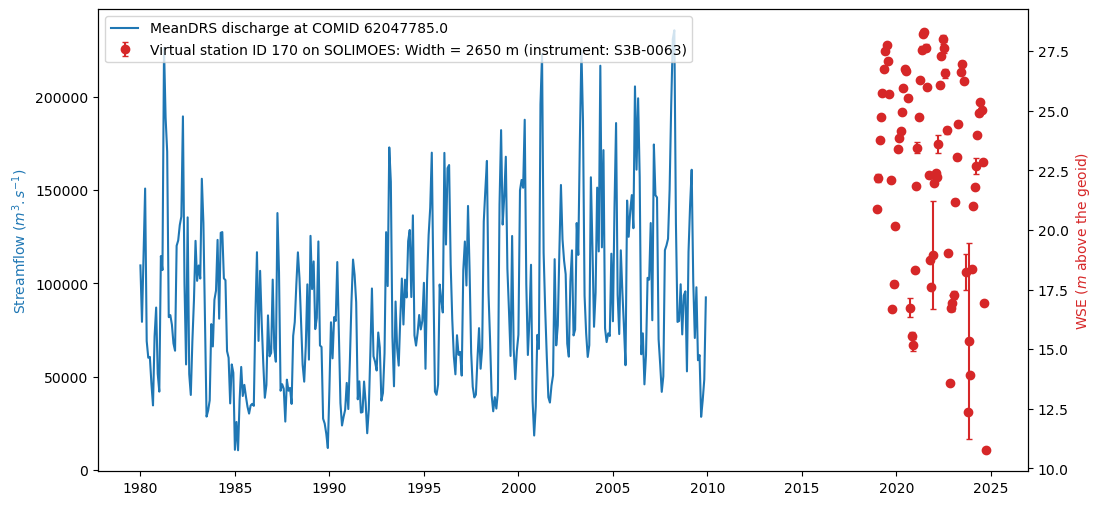

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


2
3
4
5


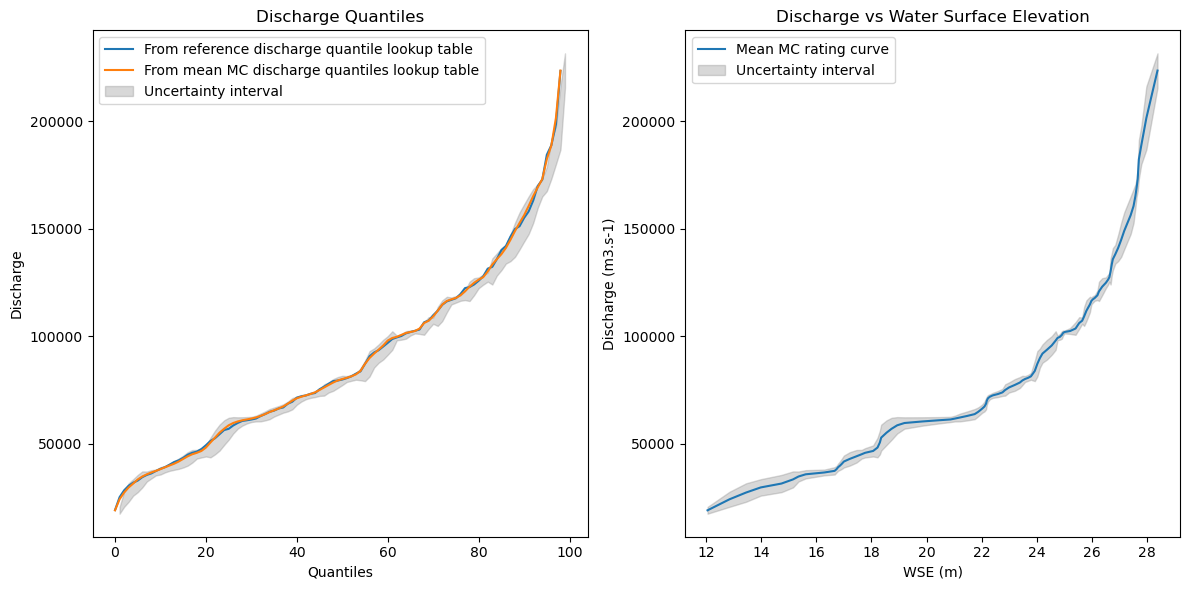

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.28 ; Corr: 0.48 ; NBIAS: 0.03 ; NSTDERR: 0.5 ; NRMSE: 0.41 ; PRMSE: 0.39 ; RRMSE: 0.44


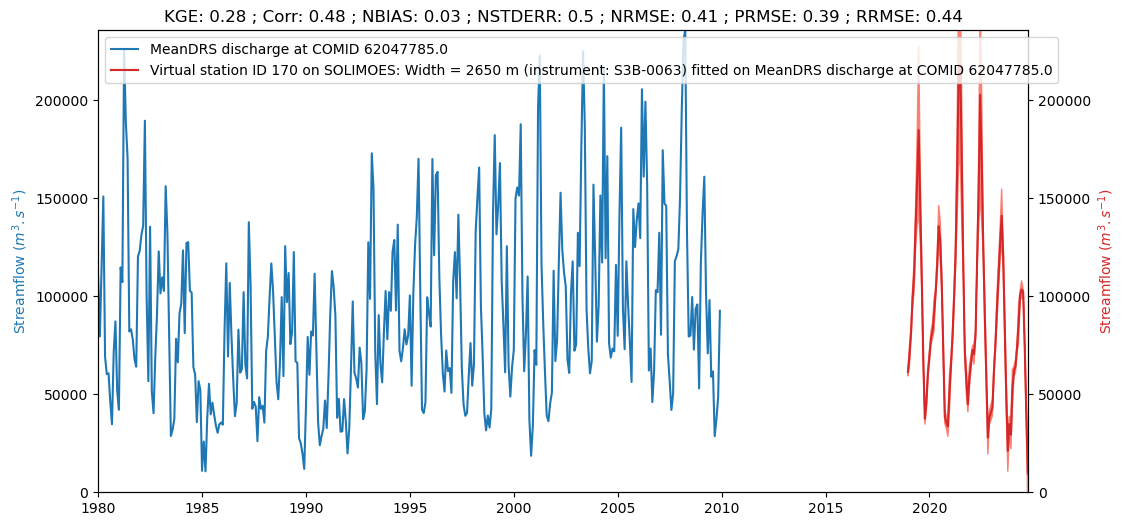

3436 ############################


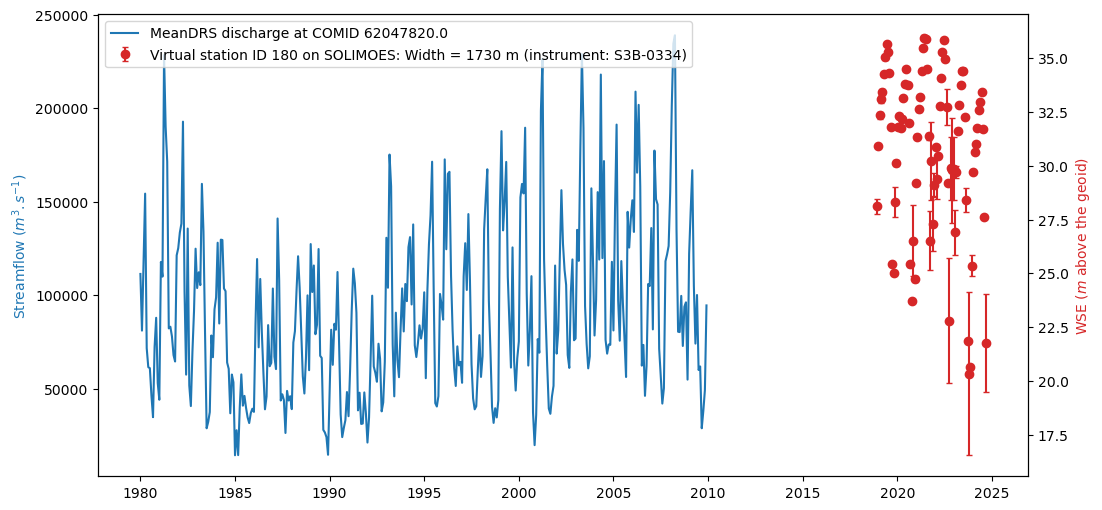

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


2
3
4
5


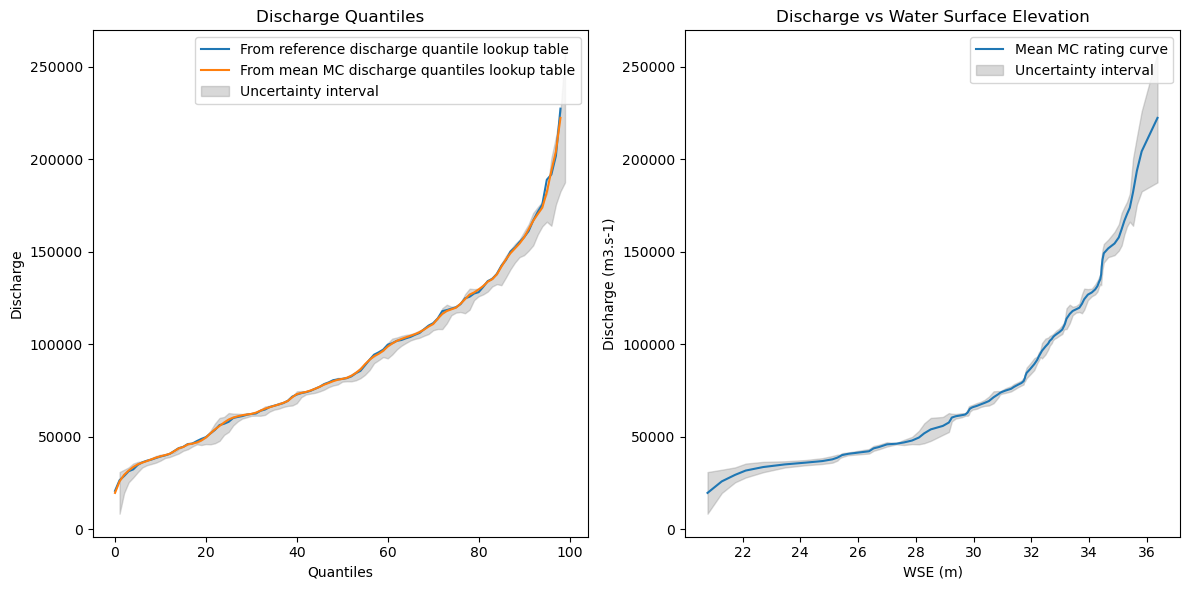

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.38 ; Corr: 0.6 ; NBIAS: 0.02 ; NSTDERR: 0.48 ; NRMSE: 0.36 ; PRMSE: 0.35 ; RRMSE: 0.38


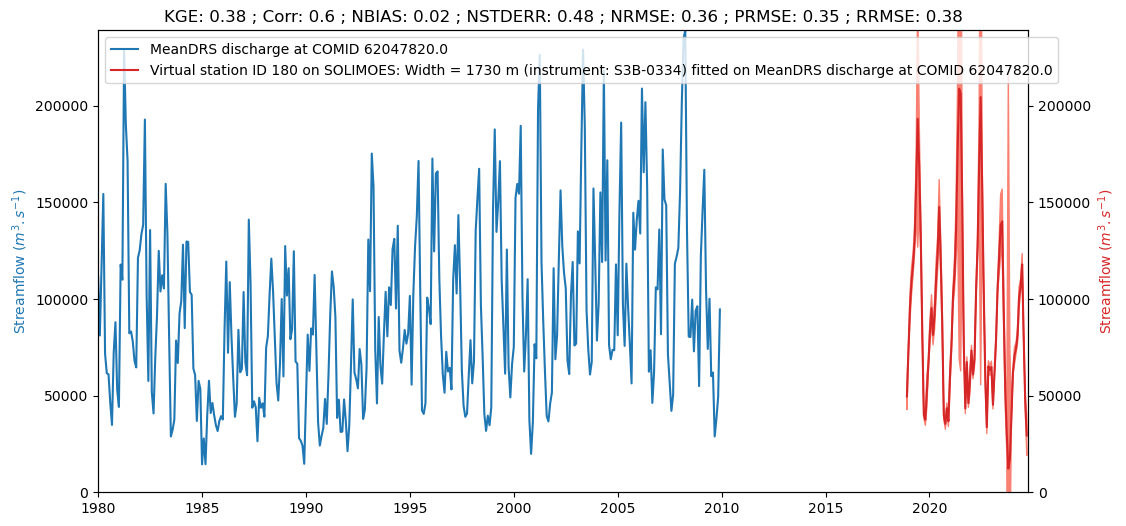

4515 ############################


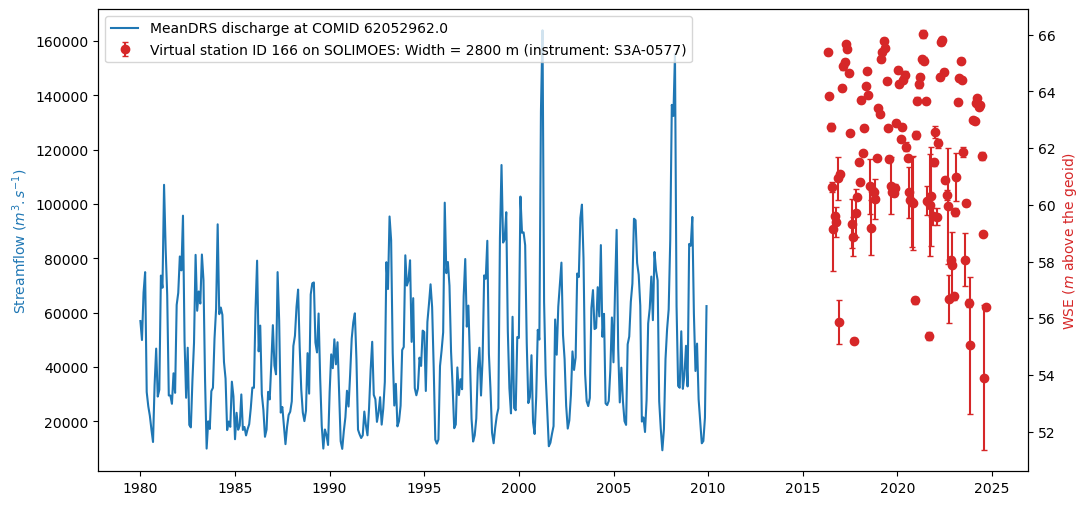

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


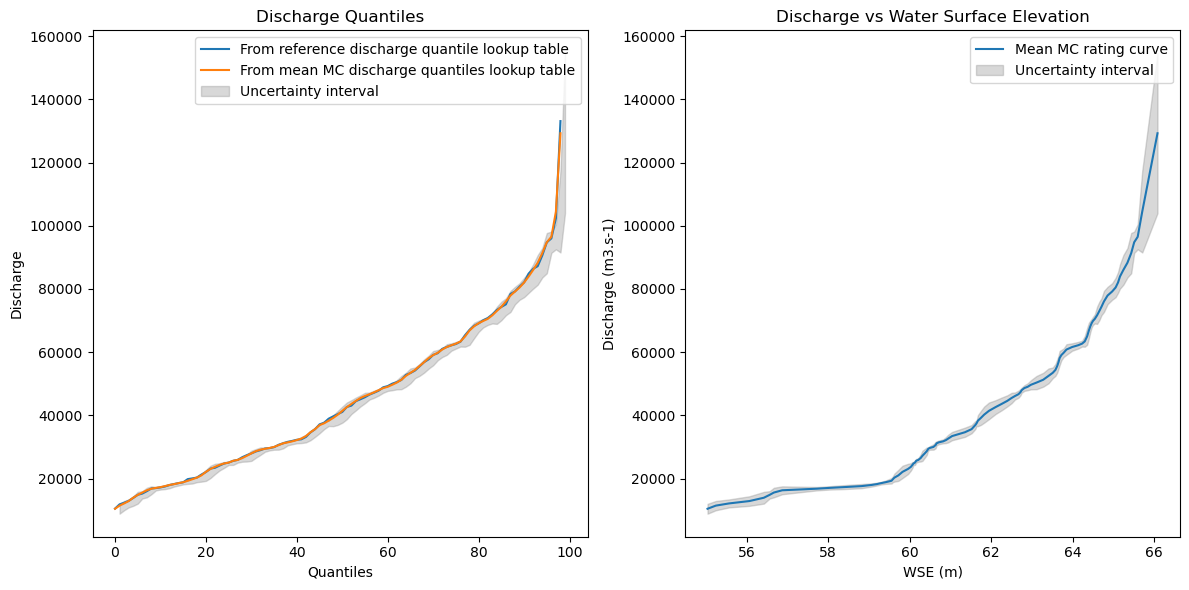

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.8 ; Corr: 0.87 ; NBIAS: 0.01 ; NSTDERR: 0.14 ; NRMSE: 0.24 ; PRMSE: 0.22 ; RRMSE: 0.2


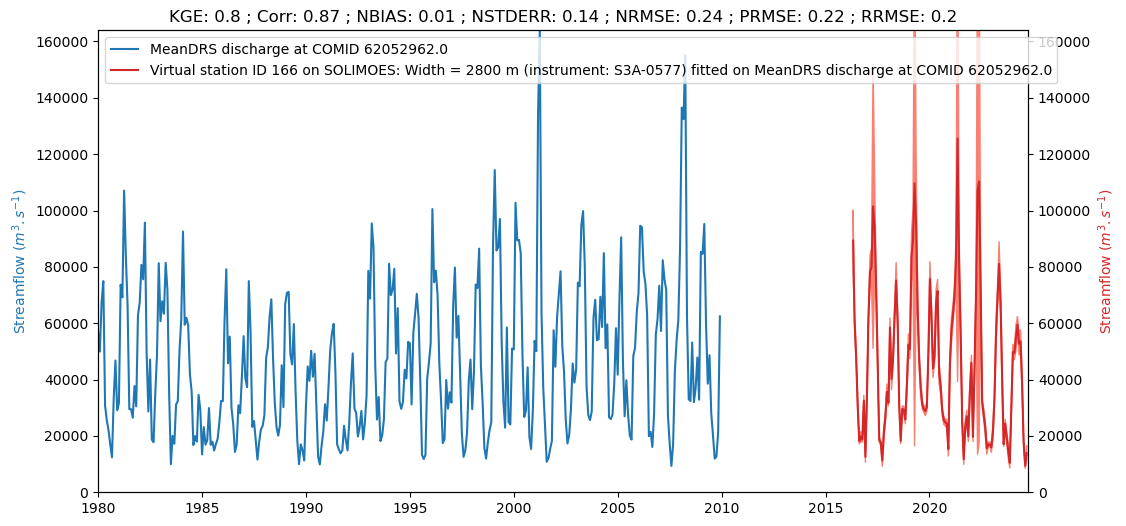

6202 ############################


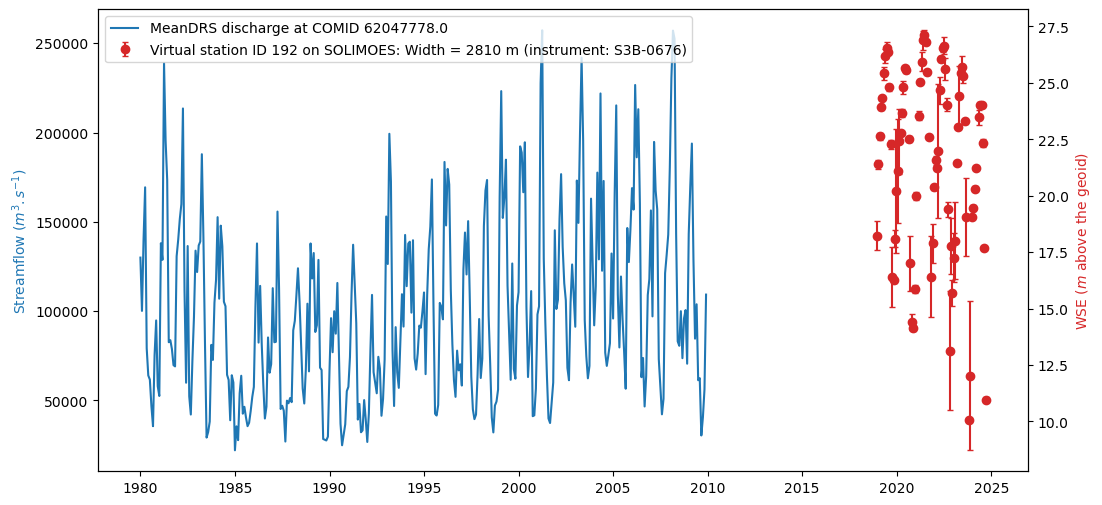

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


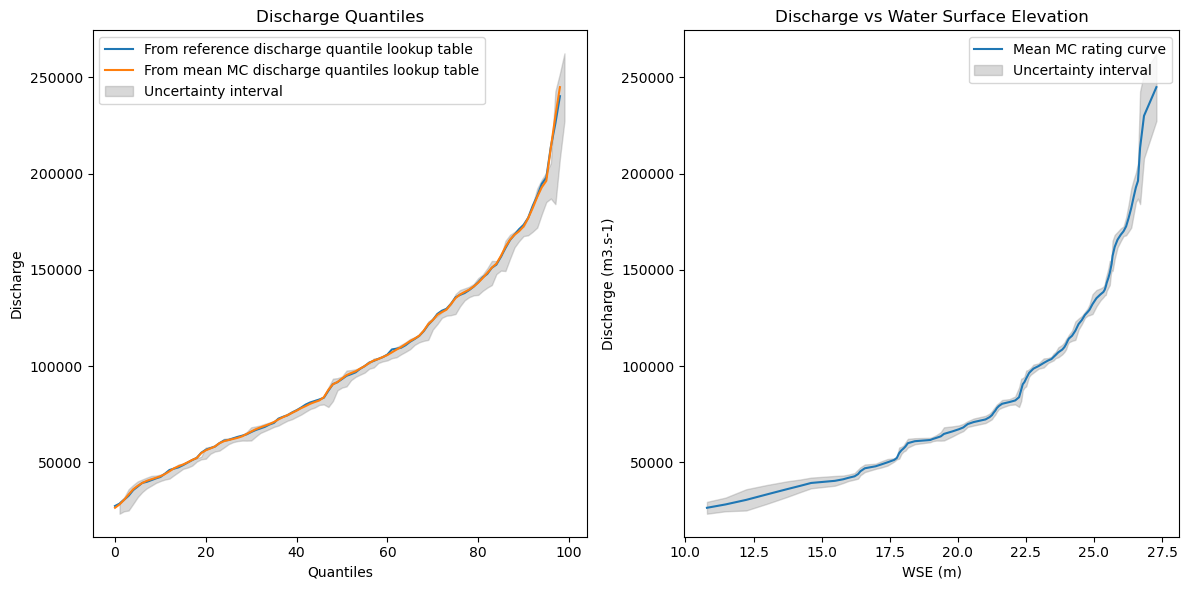

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.27 ; Corr: 0.37 ; NBIAS: 0.02 ; NSTDERR: 0.36 ; NRMSE: 0.46 ; PRMSE: 0.43 ; RRMSE: 0.45


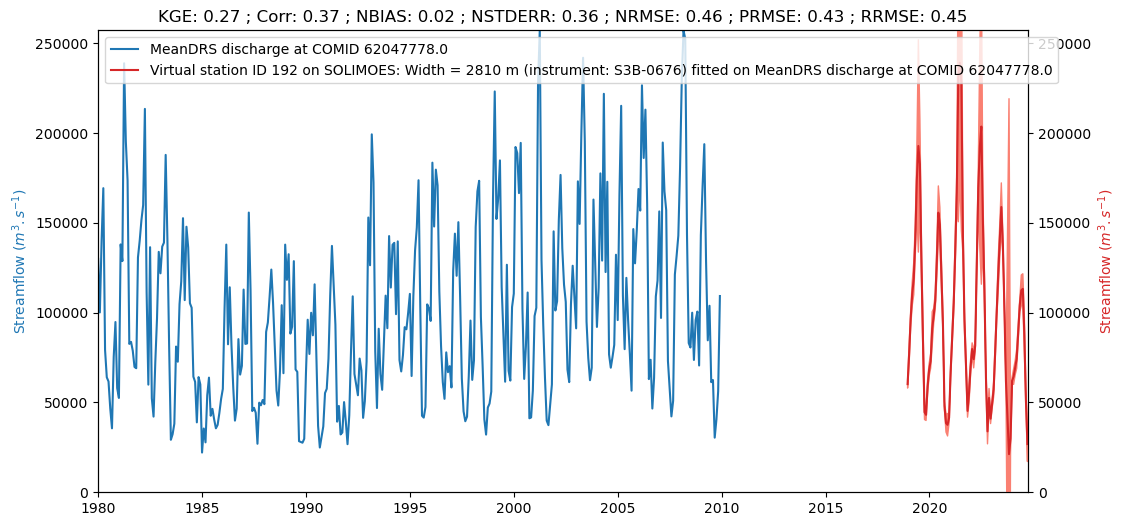

8082 ############################


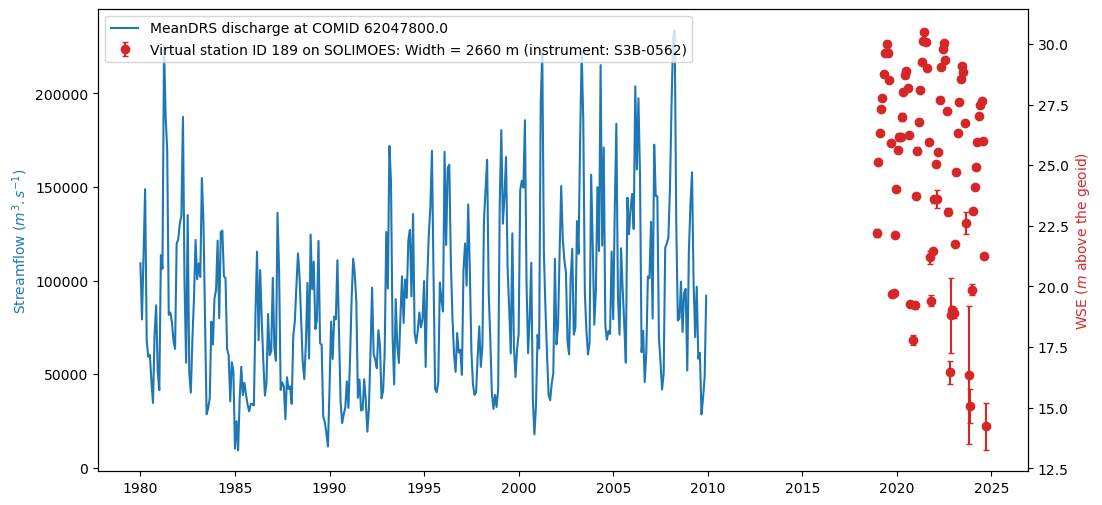

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4


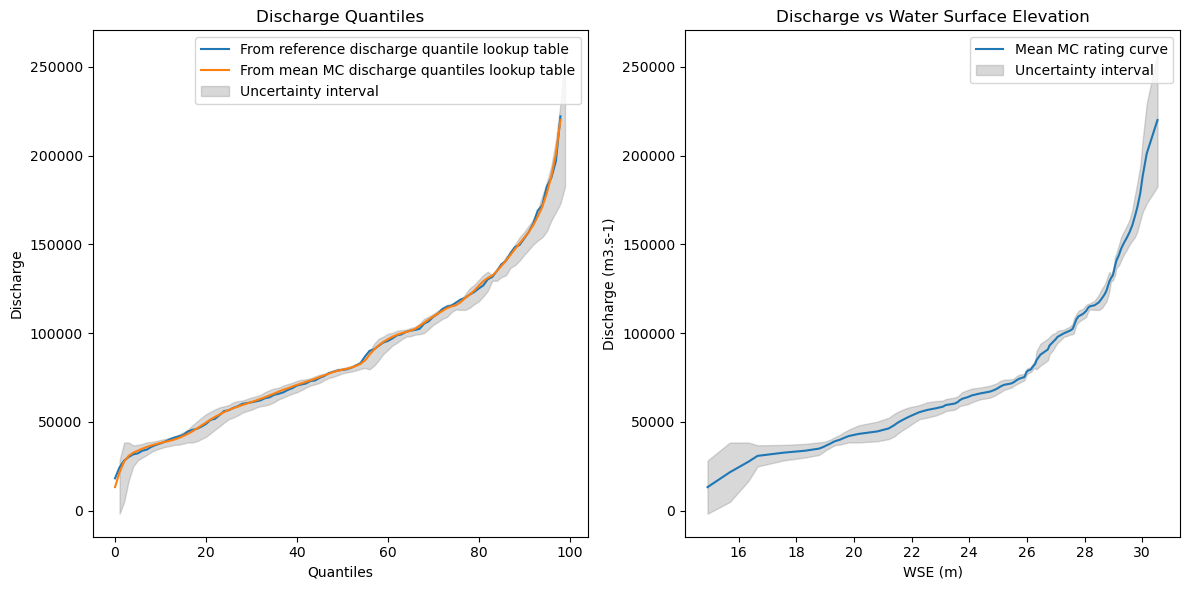

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.29 ; Corr: 0.52 ; NBIAS: 0.02 ; NSTDERR: 0.52 ; NRMSE: 0.4 ; PRMSE: 0.38 ; RRMSE: 0.43


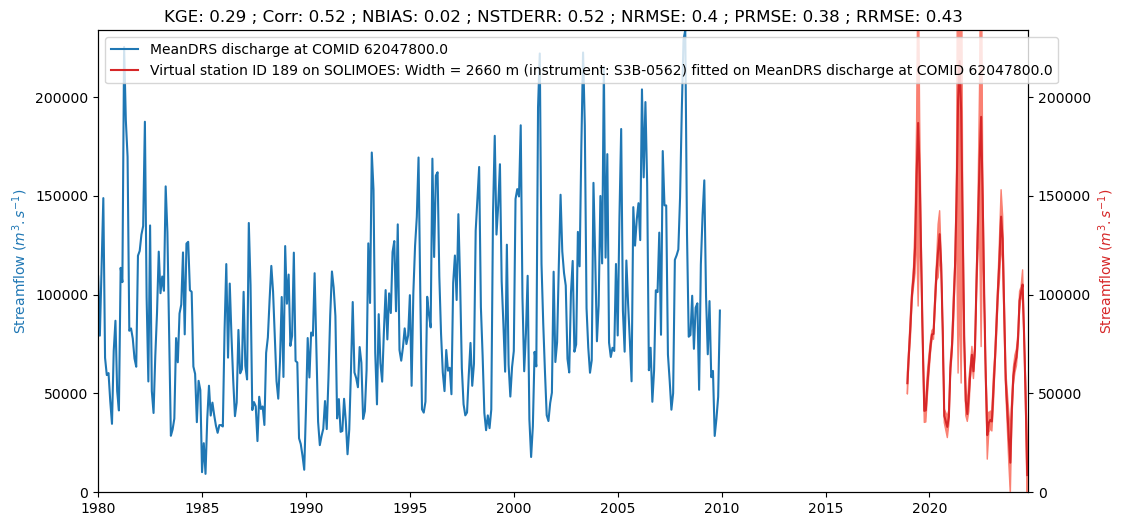

9968 ############################


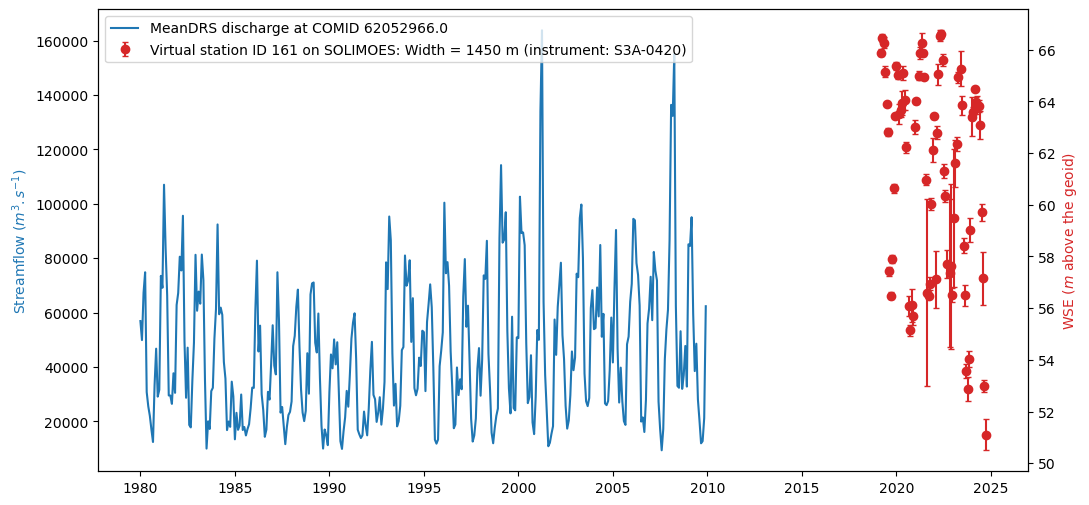

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


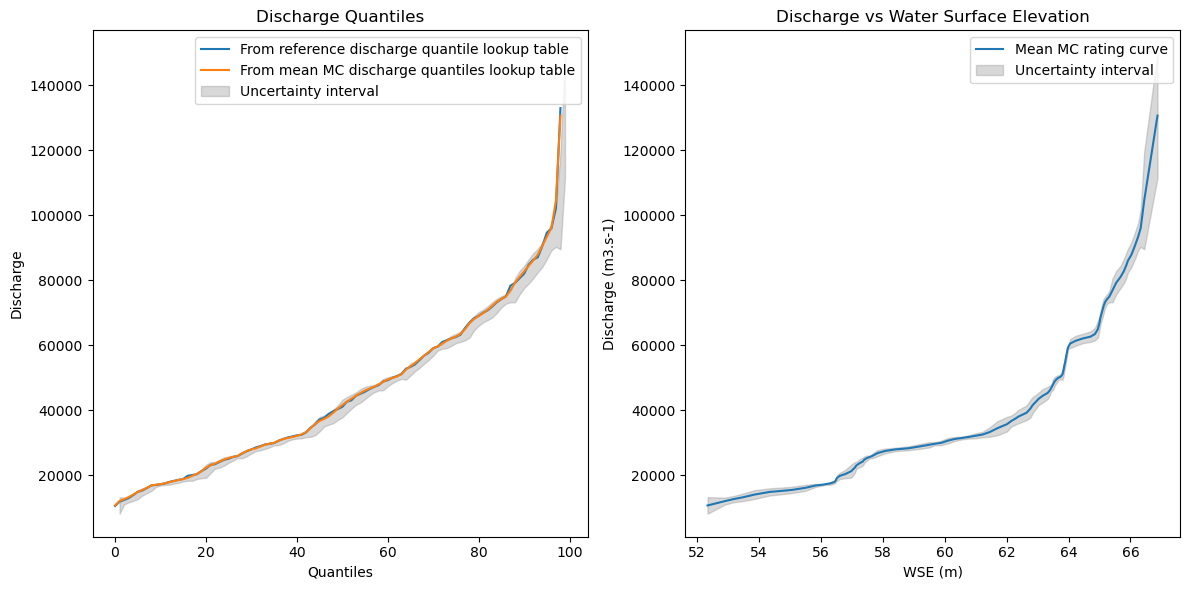

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.79 ; Corr: 0.84 ; NBIAS: 0.03 ; NSTDERR: 0.12 ; NRMSE: 0.26 ; PRMSE: 0.24 ; RRMSE: 0.22


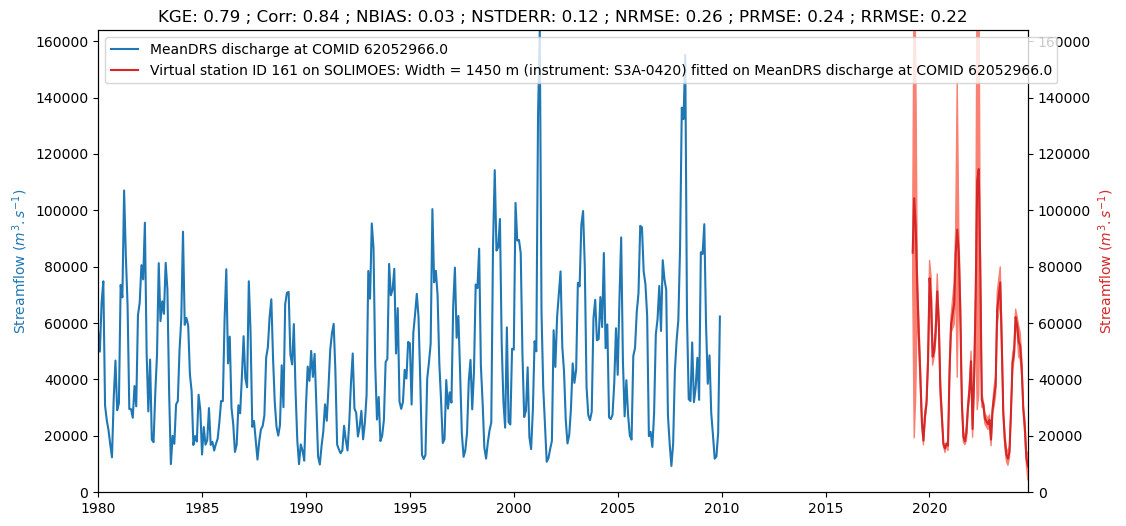

13125 ############################


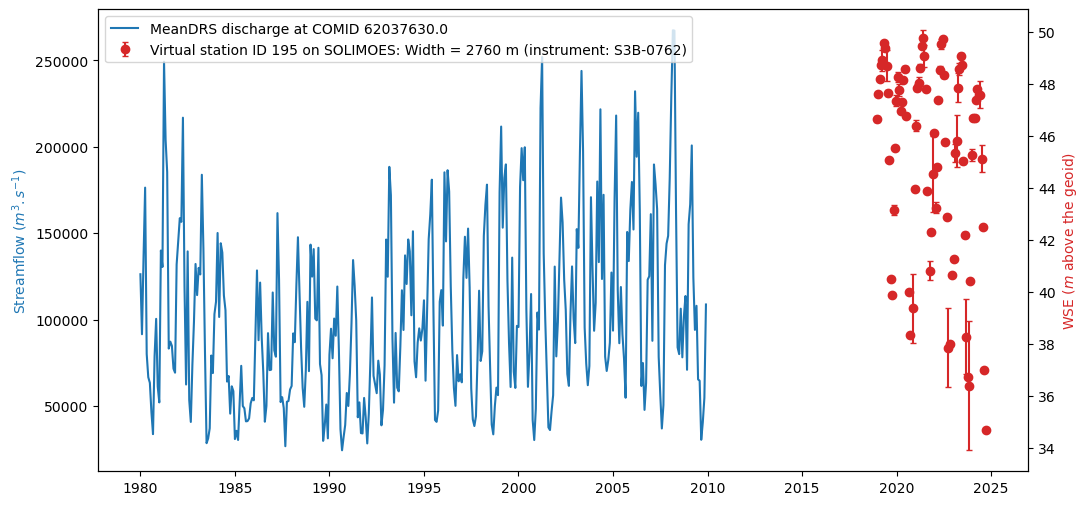

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


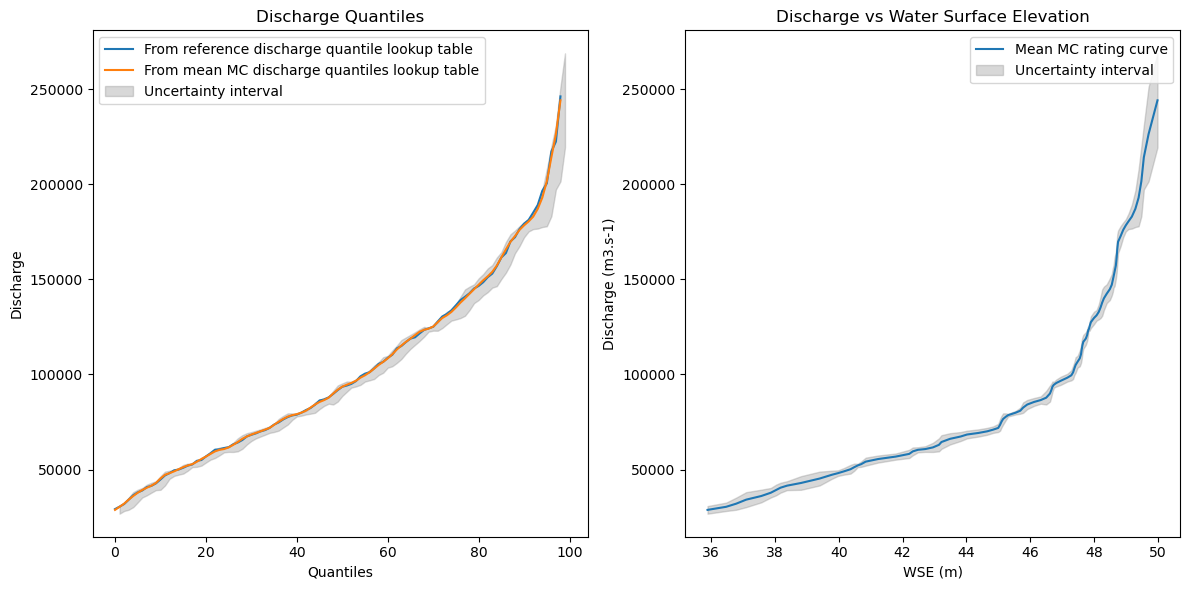

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.62 ; Corr: 0.82 ; NBIAS: 0.05 ; NSTDERR: 0.33 ; NRMSE: 0.26 ; PRMSE: 0.24 ; RRMSE: 0.25


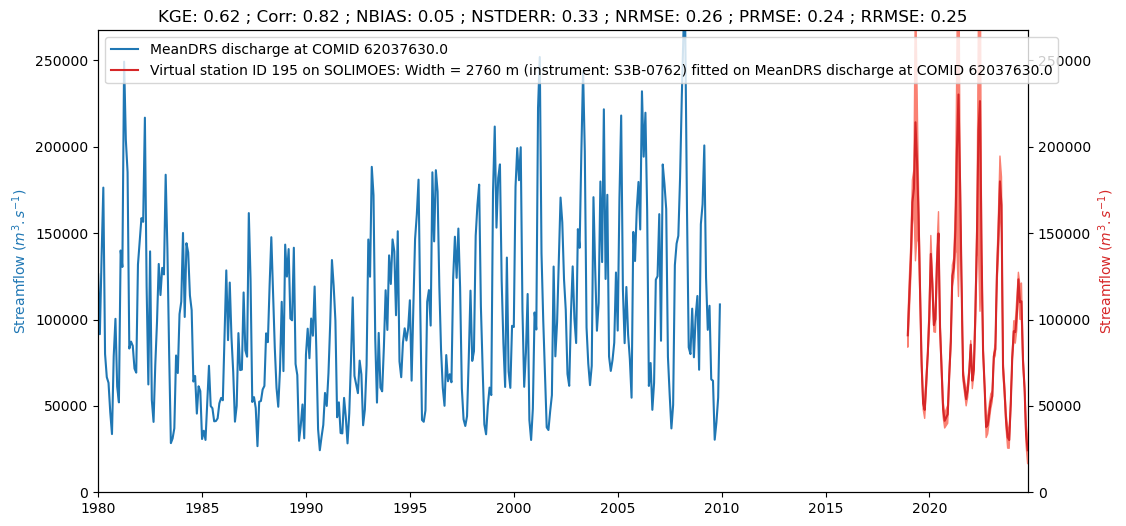

13723 ############################


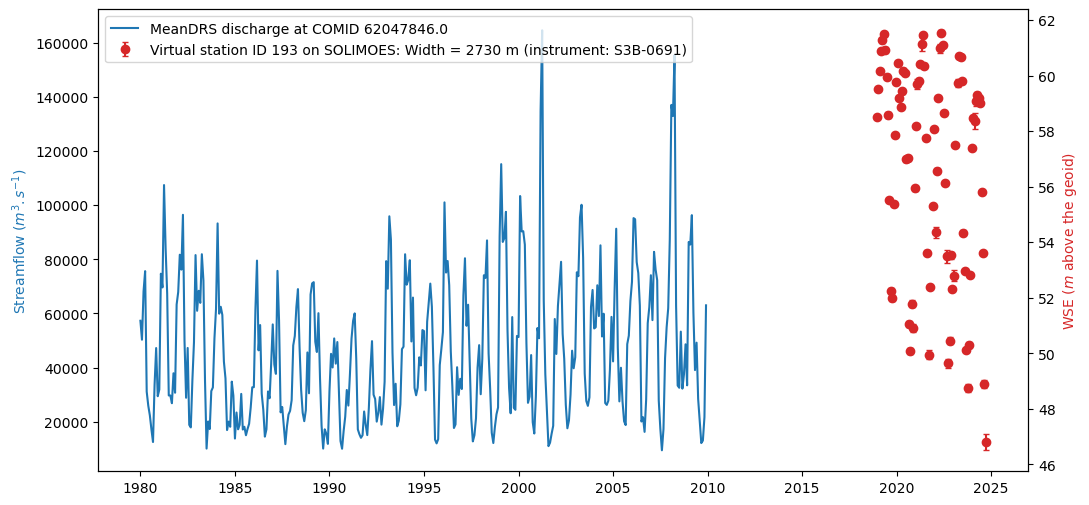

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


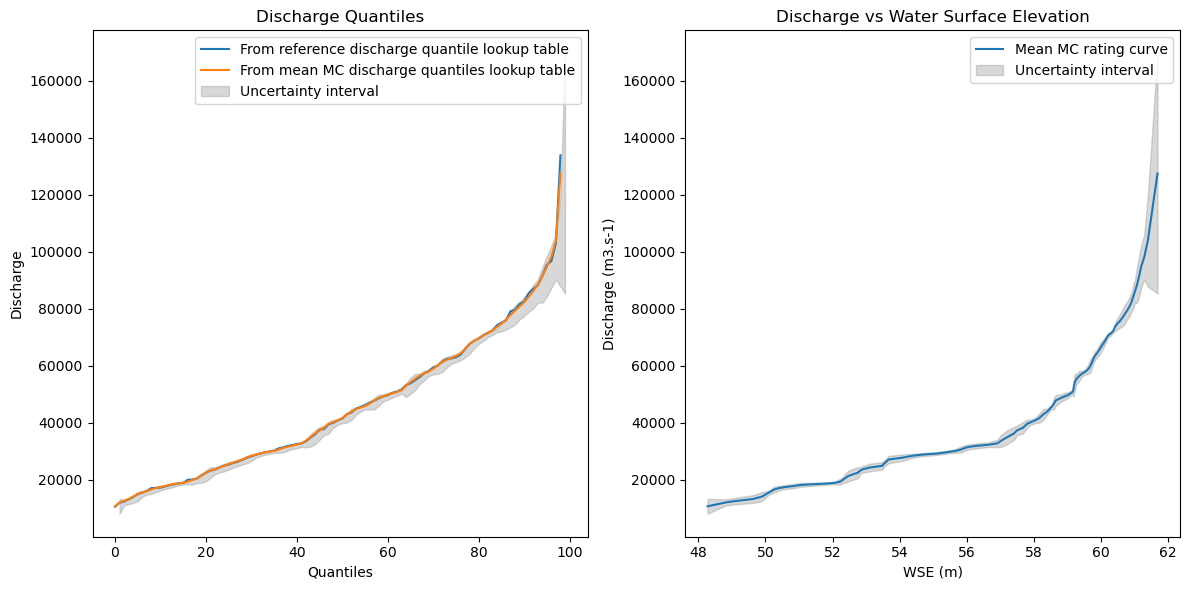

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.77 ; Corr: 0.82 ; NBIAS: 0.03 ; NSTDERR: 0.15 ; NRMSE: 0.28 ; PRMSE: 0.26 ; RRMSE: 0.23


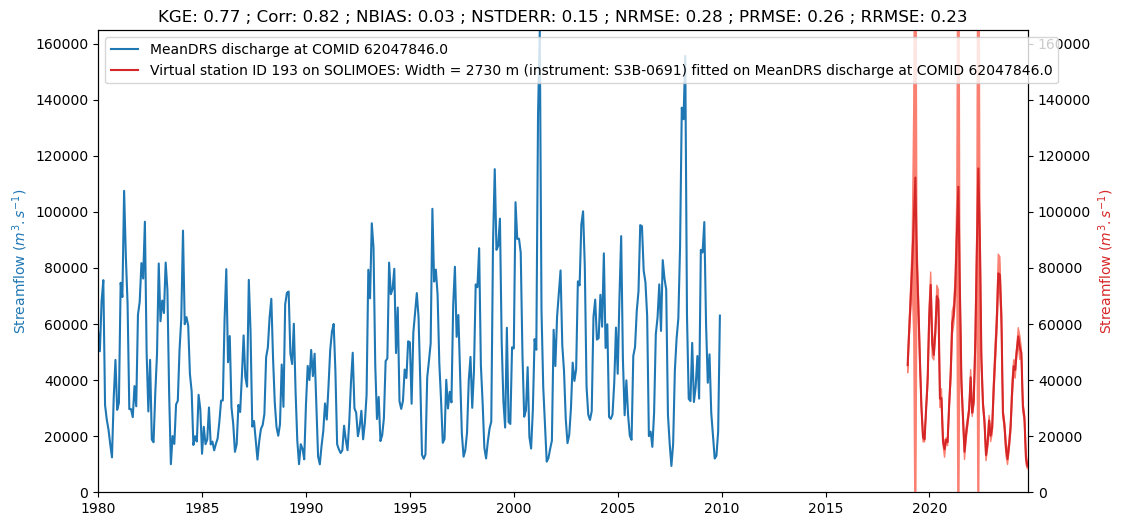

13997 ############################


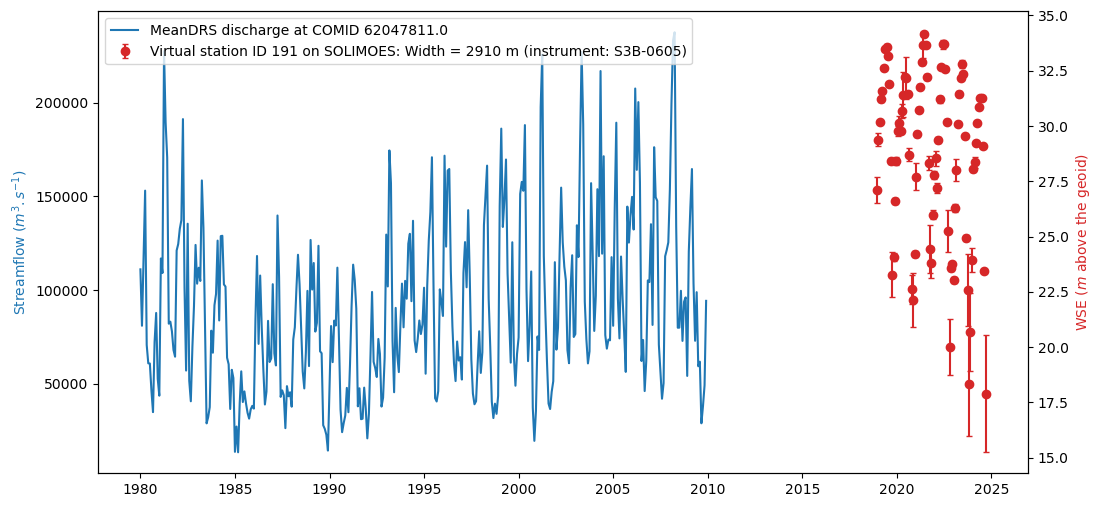

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


3
4
5


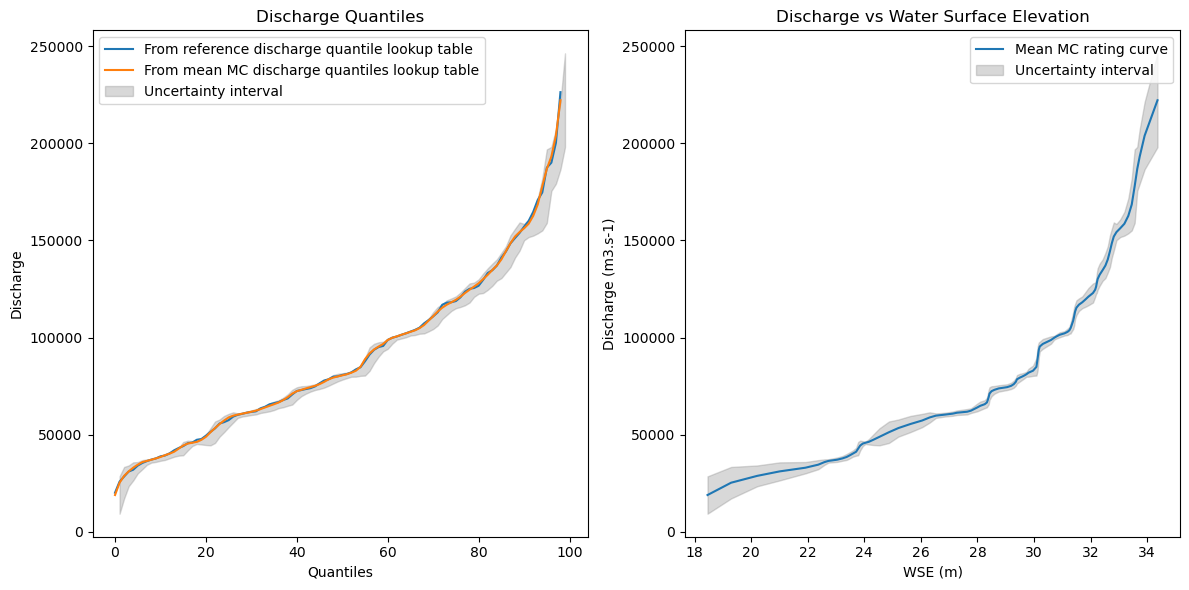

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.39 ; Corr: 0.56 ; NBIAS: 0.02 ; NSTDERR: 0.42 ; NRMSE: 0.37 ; PRMSE: 0.35 ; RRMSE: 0.39


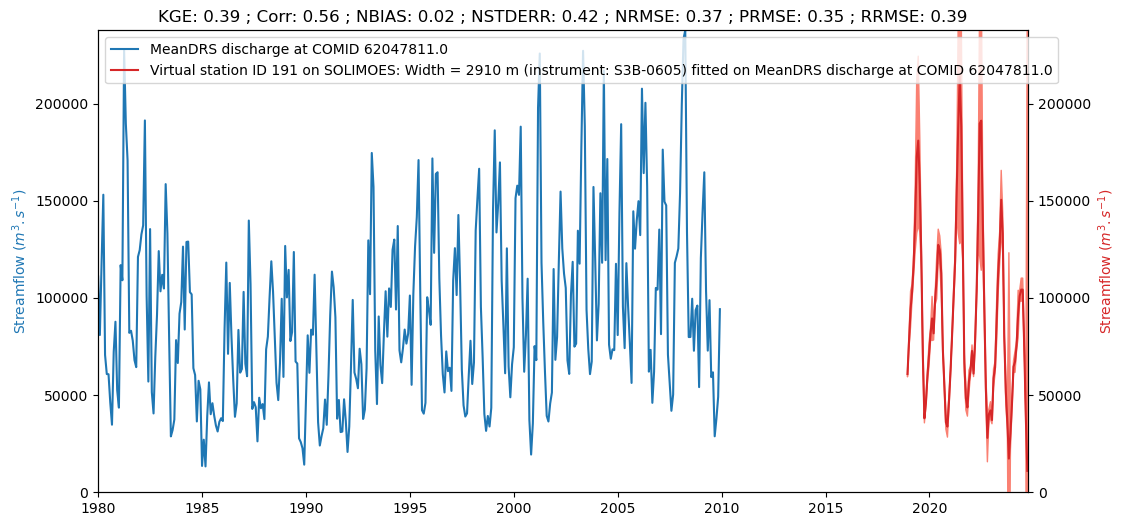

14767 ############################


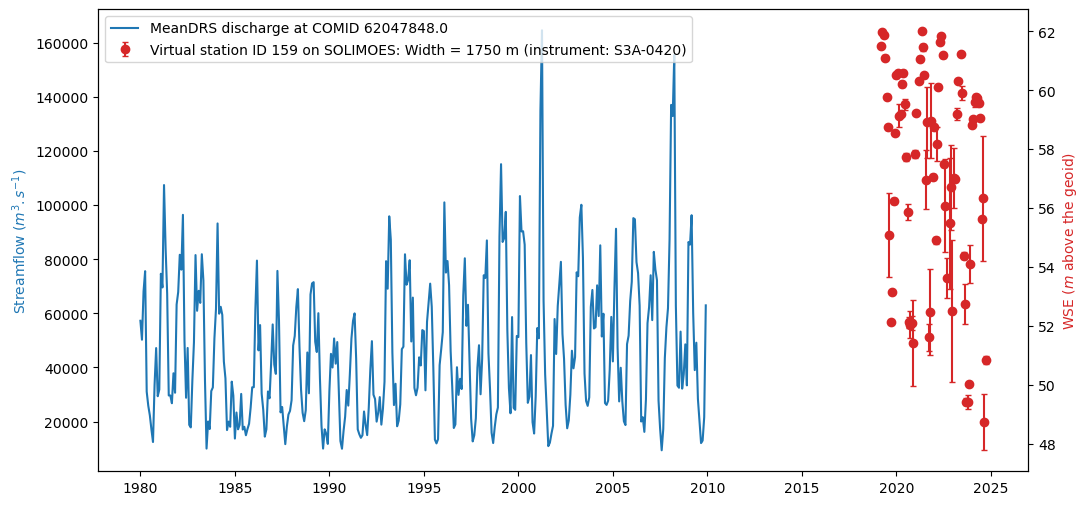

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


2
3
4
5


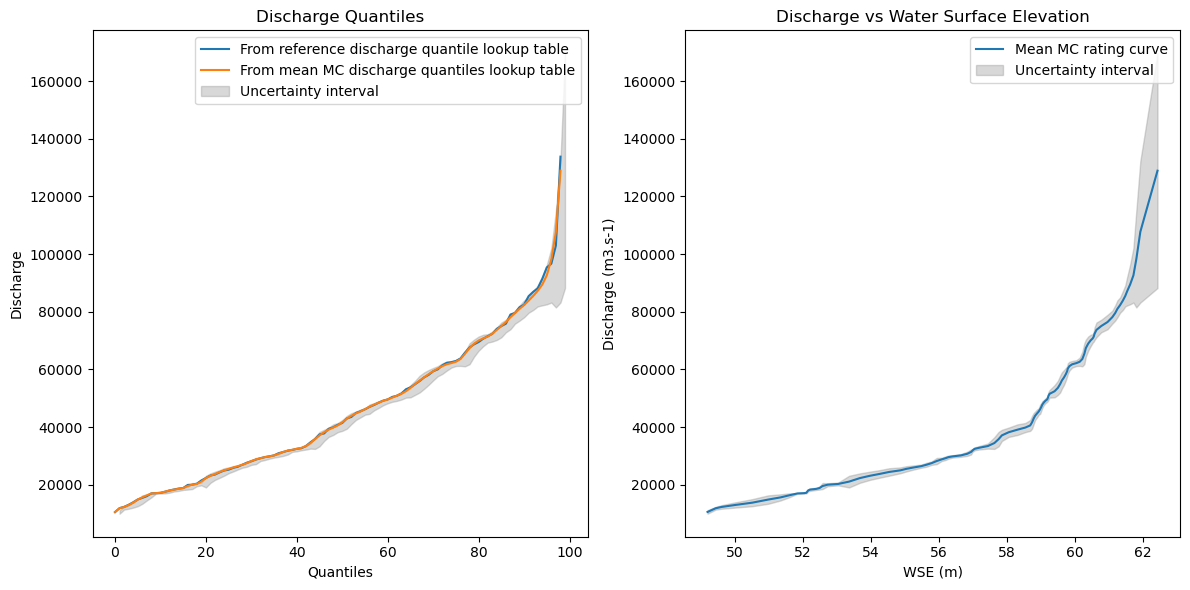

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.76 ; Corr: 0.8 ; NBIAS: 0.03 ; NSTDERR: 0.13 ; NRMSE: 0.29 ; PRMSE: 0.27 ; RRMSE: 0.24


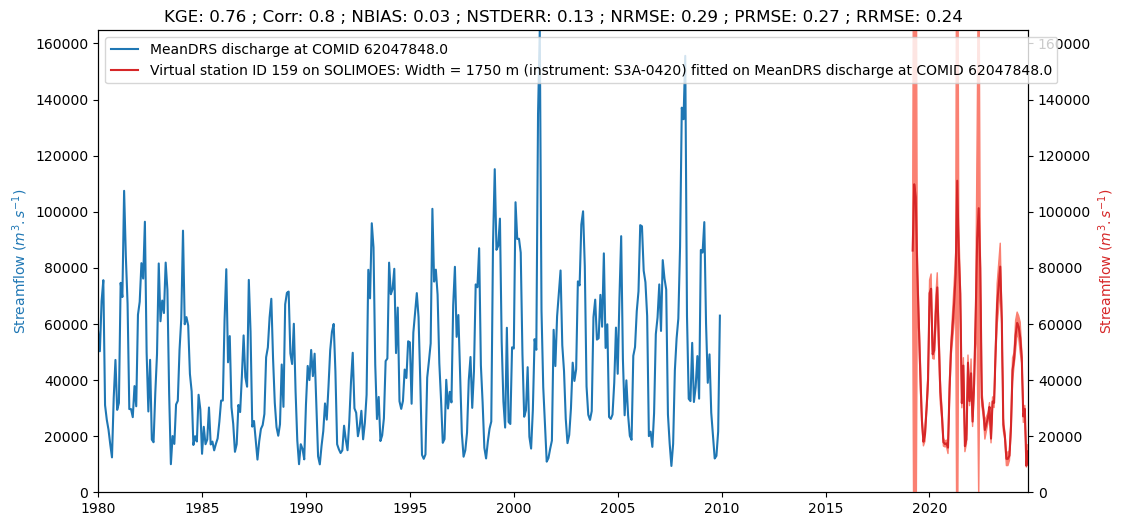

15982 ############################


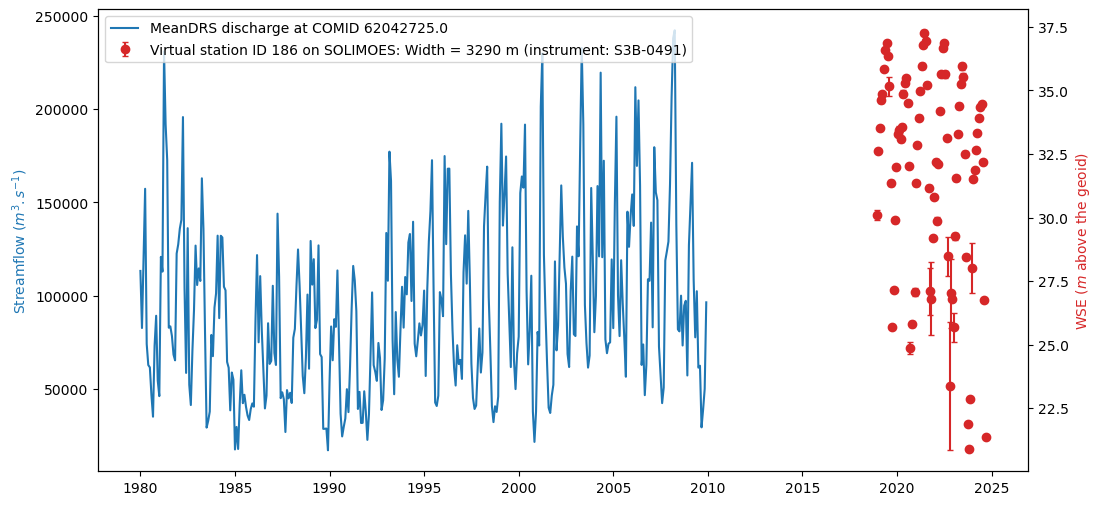

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


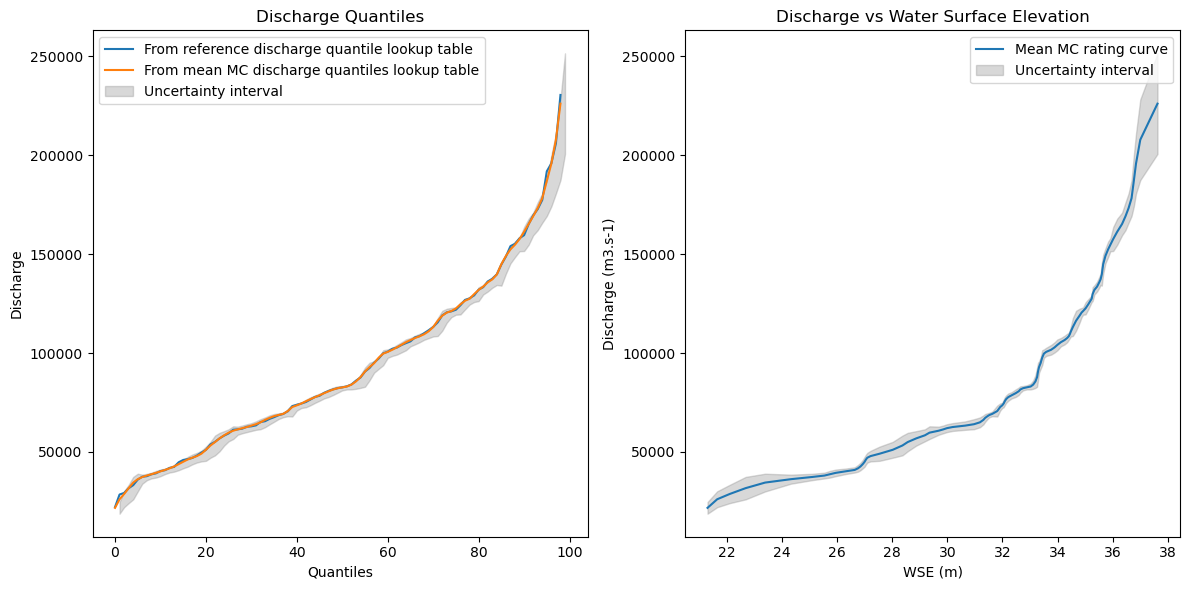

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.4 ; Corr: 0.59 ; NBIAS: 0.01 ; NSTDERR: 0.44 ; NRMSE: 0.36 ; PRMSE: 0.35 ; RRMSE: 0.38


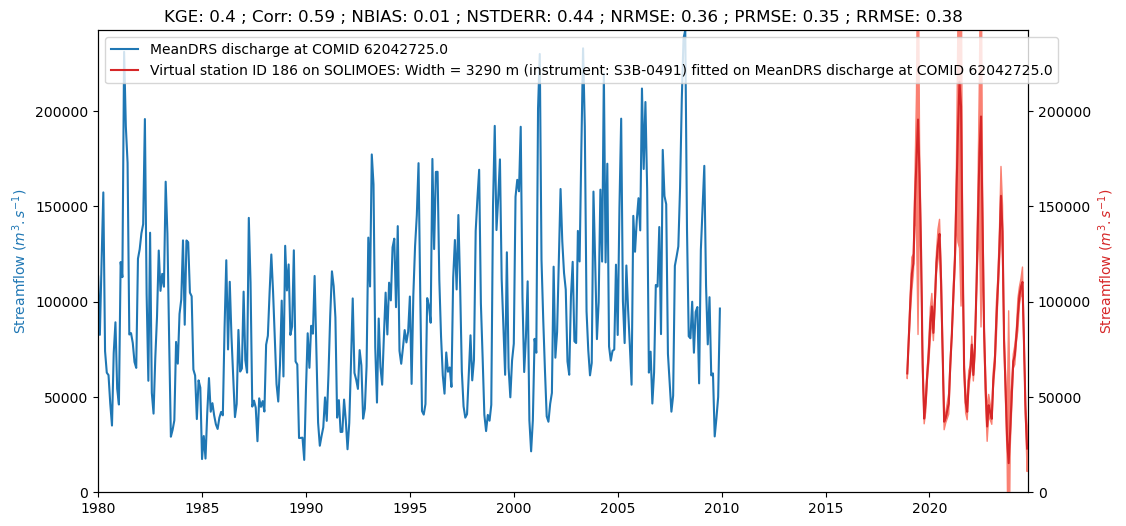

18784 ############################


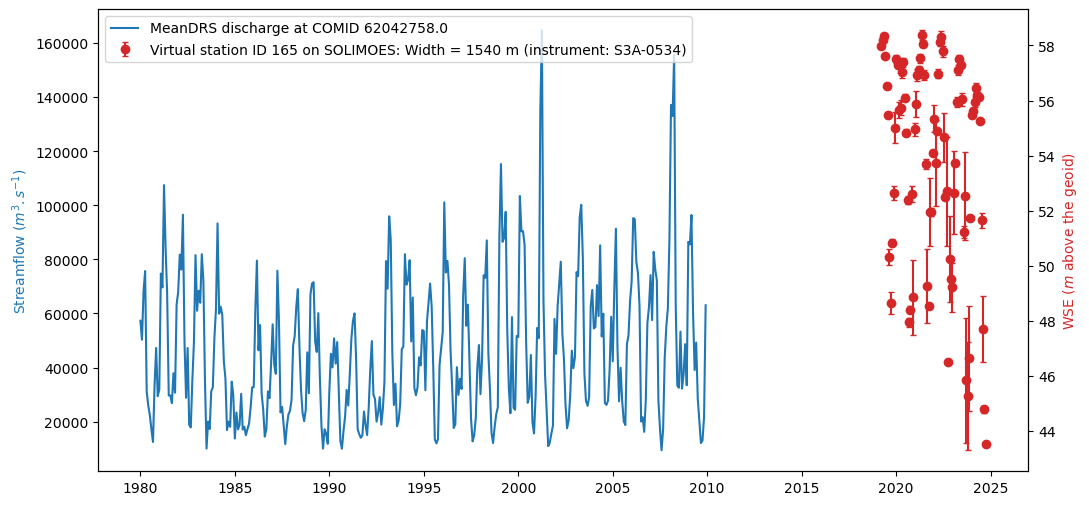

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


2
3
4
5


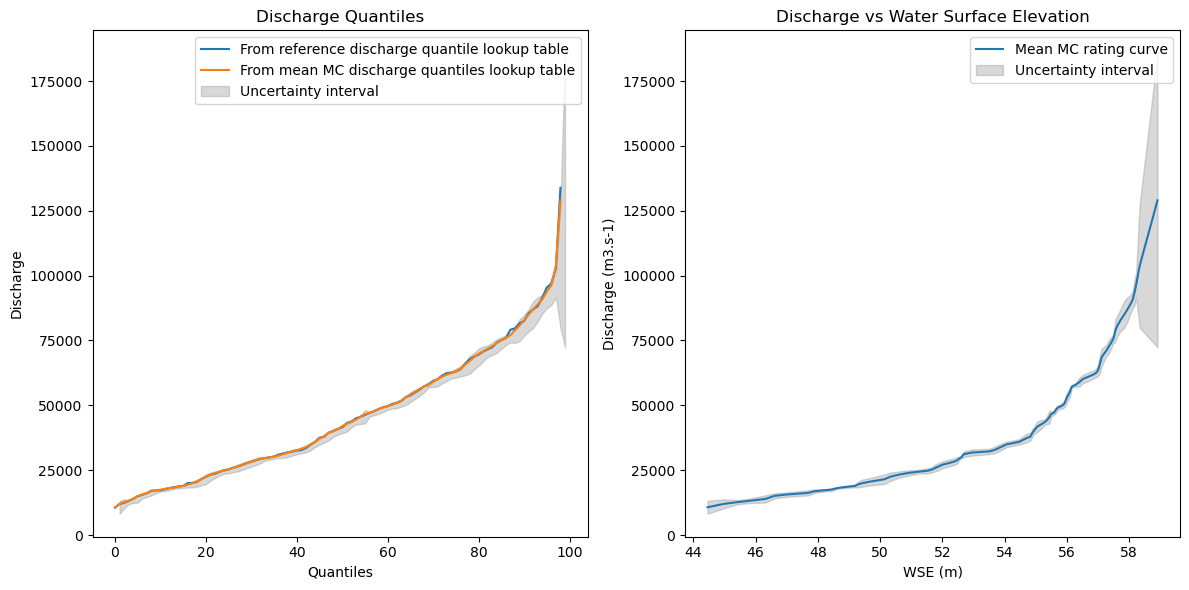

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.76 ; Corr: 0.81 ; NBIAS: 0.02 ; NSTDERR: 0.14 ; NRMSE: 0.28 ; PRMSE: 0.26 ; RRMSE: 0.24


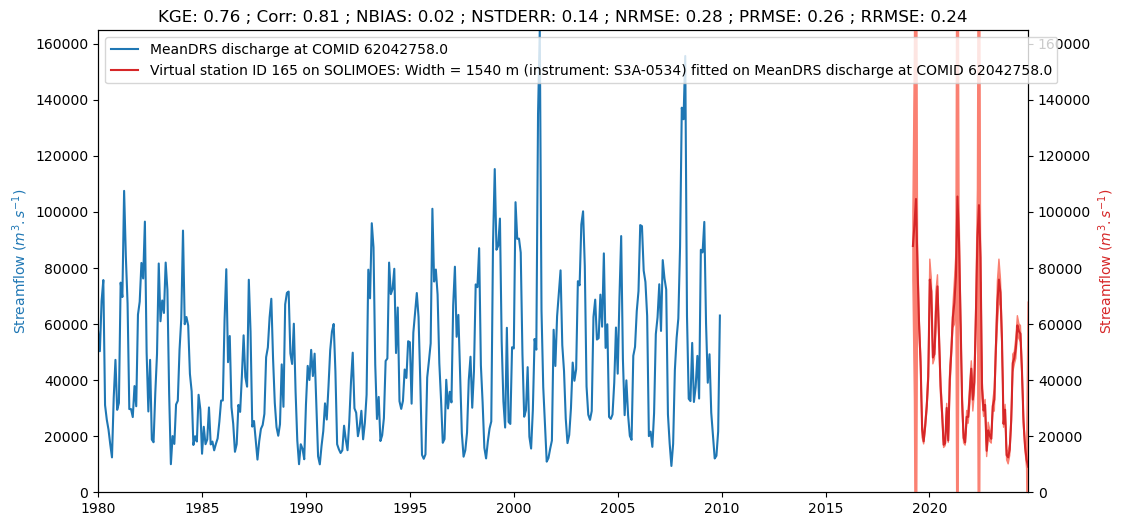

19081 ############################


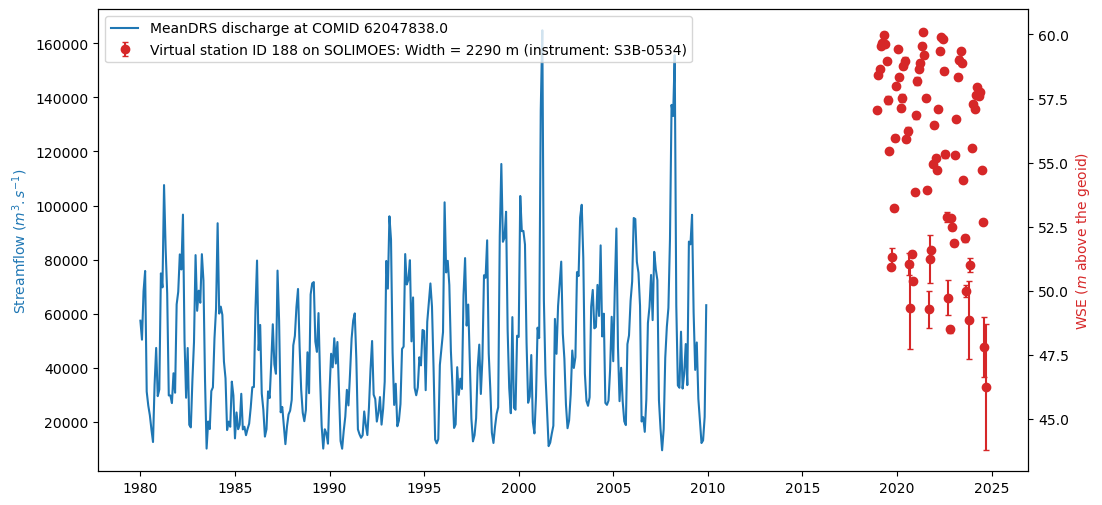

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


3
4
5


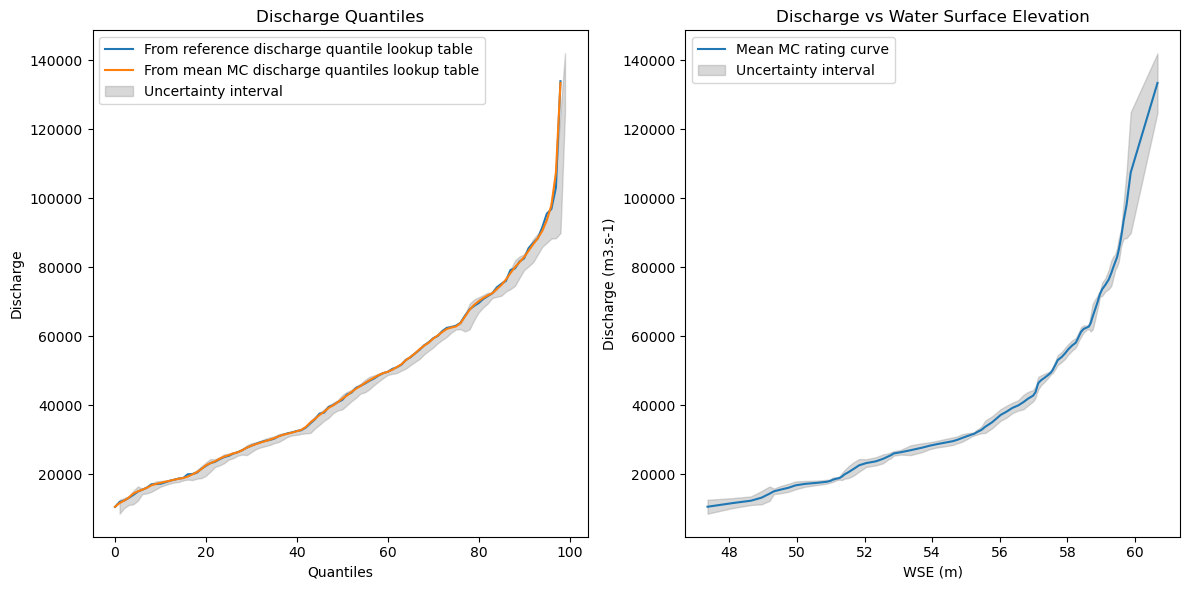

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.82 ; Corr: 0.86 ; NBIAS: 0.03 ; NSTDERR: 0.11 ; NRMSE: 0.24 ; PRMSE: 0.22 ; RRMSE: 0.2


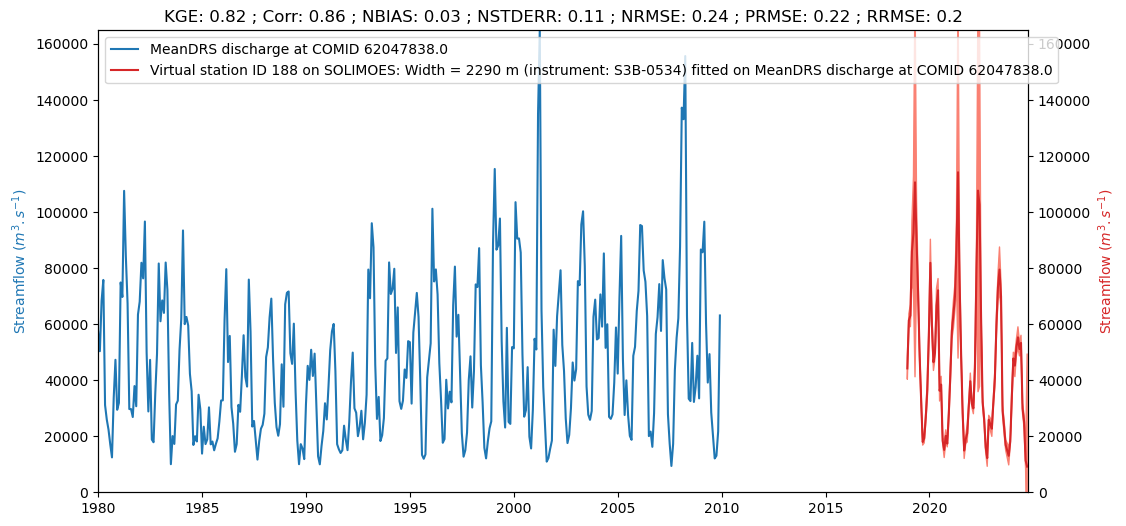

21095 ############################


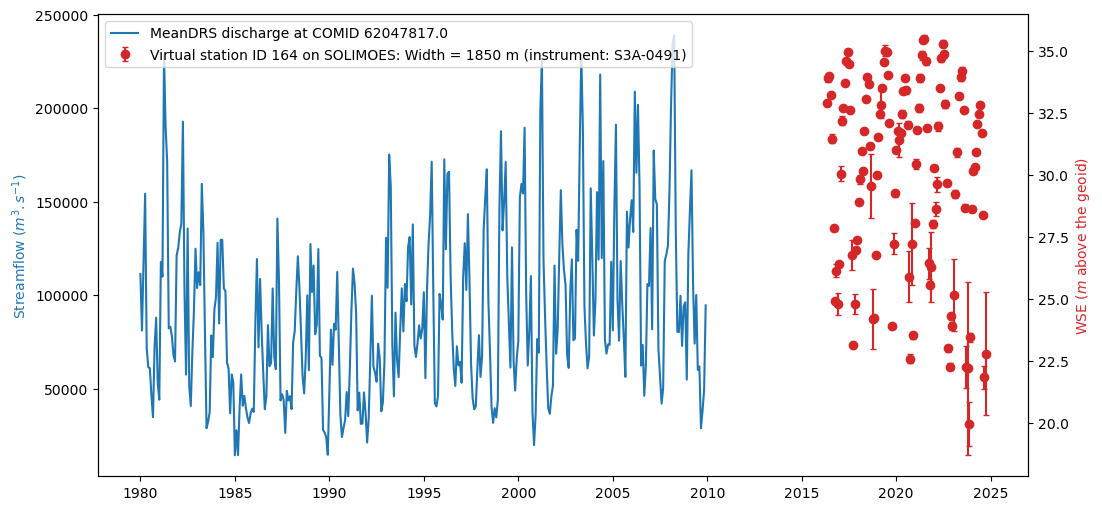

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4


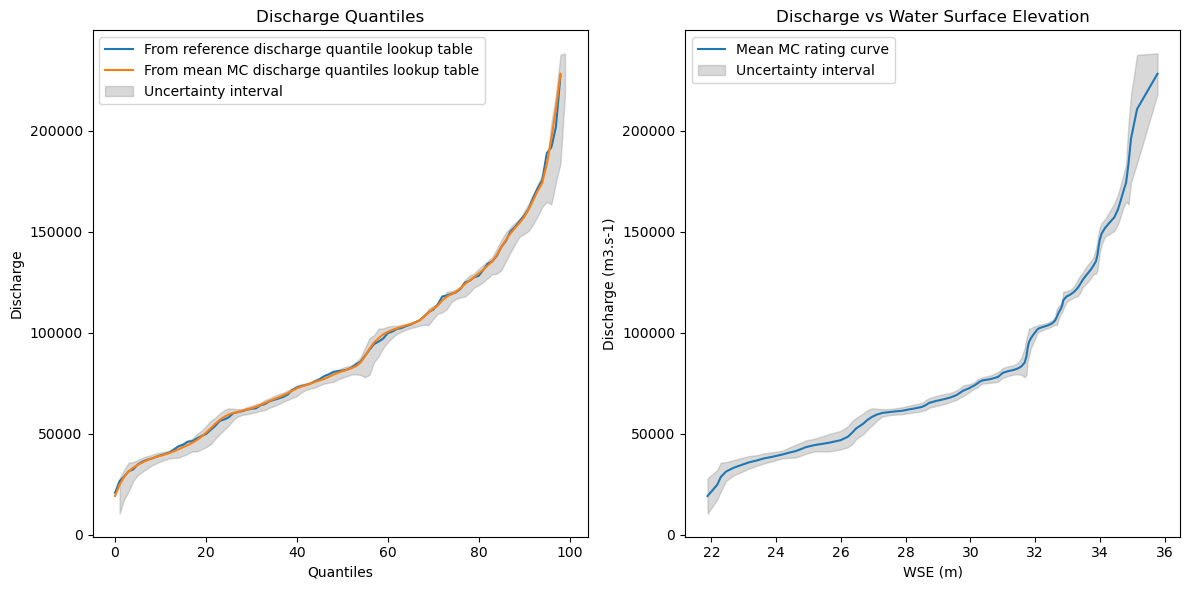

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.41 ; Corr: 0.58 ; NBIAS: 0.01 ; NSTDERR: 0.42 ; NRMSE: 0.36 ; PRMSE: 0.34 ; RRMSE: 0.38


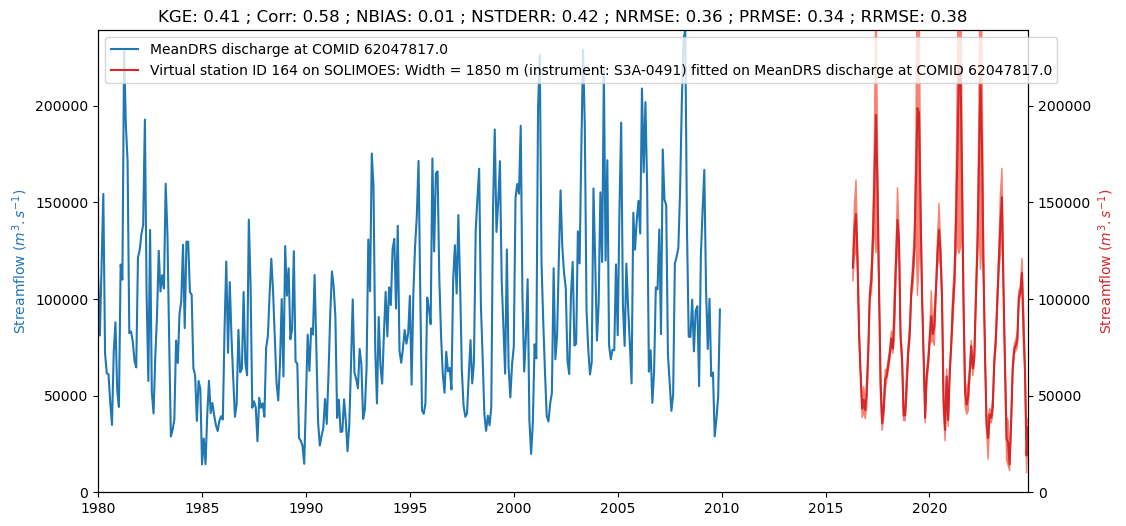

21734 ############################


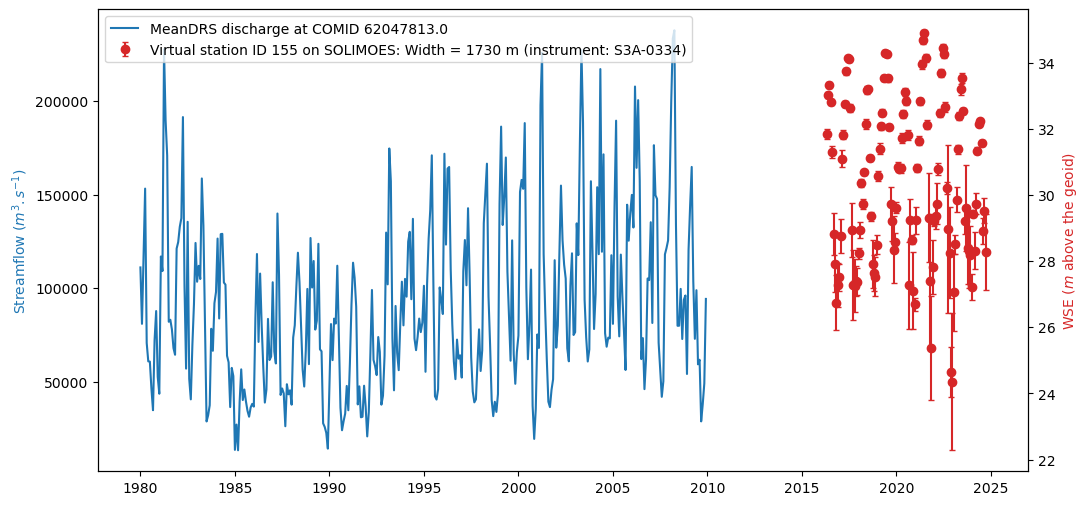

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


2
3
4


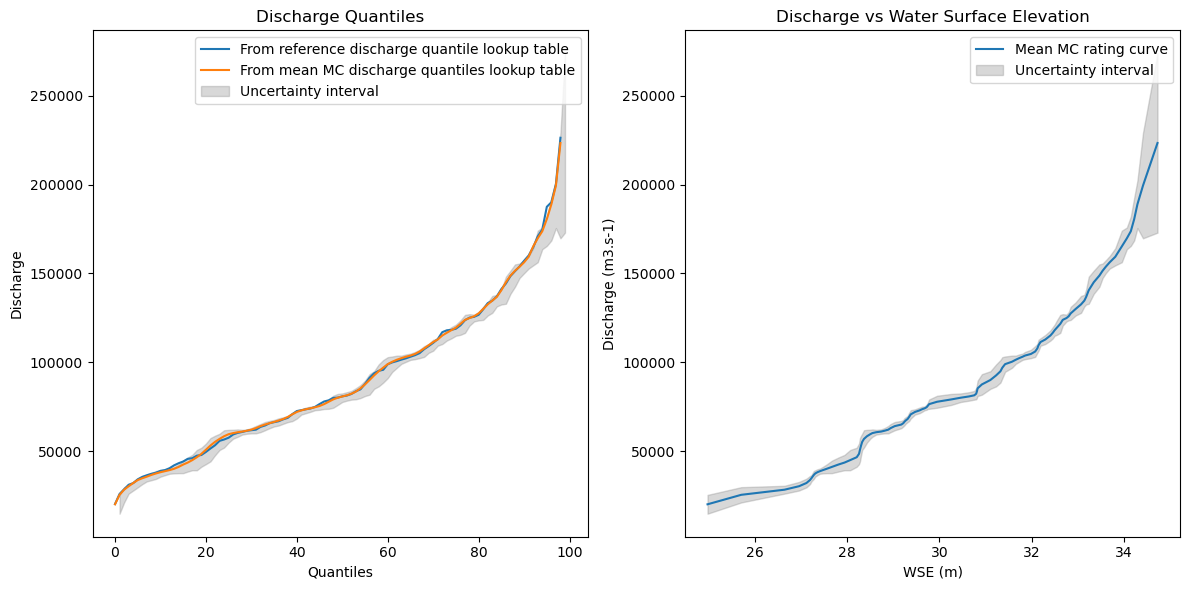

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.33 ; Corr: 0.51 ; NBIAS: 0.03 ; NSTDERR: 0.46 ; NRMSE: 0.39 ; PRMSE: 0.37 ; RRMSE: 0.41


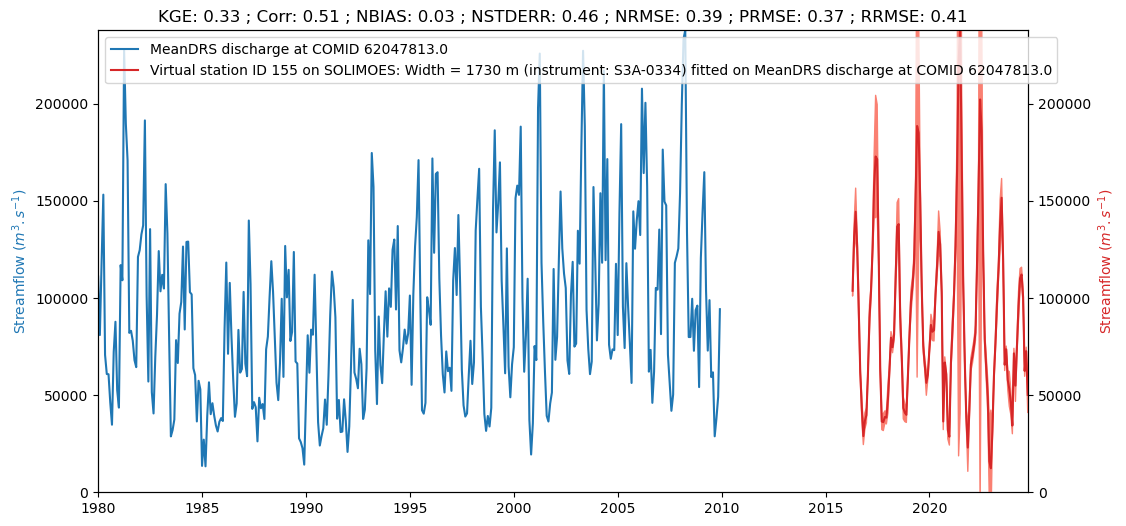

22785 ############################


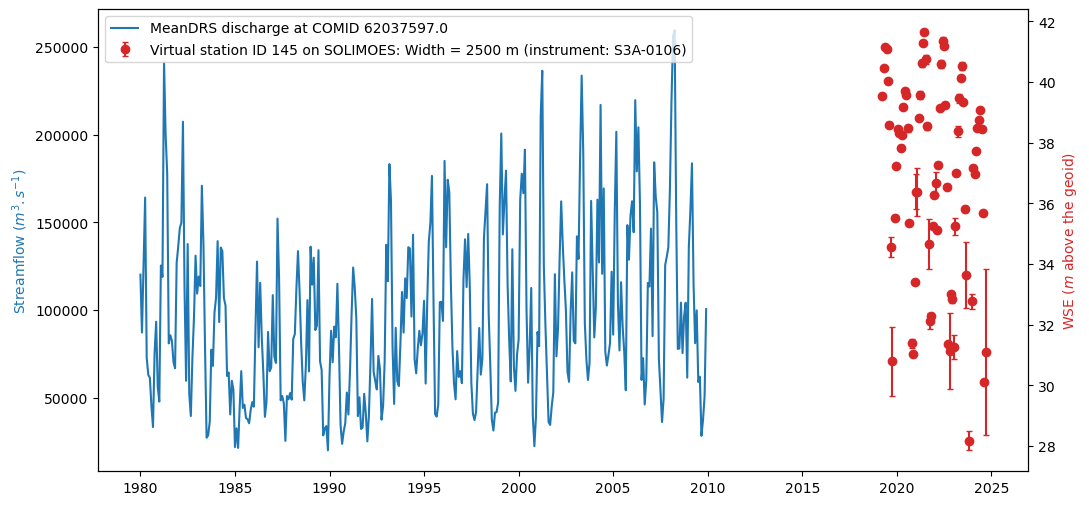

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4
5


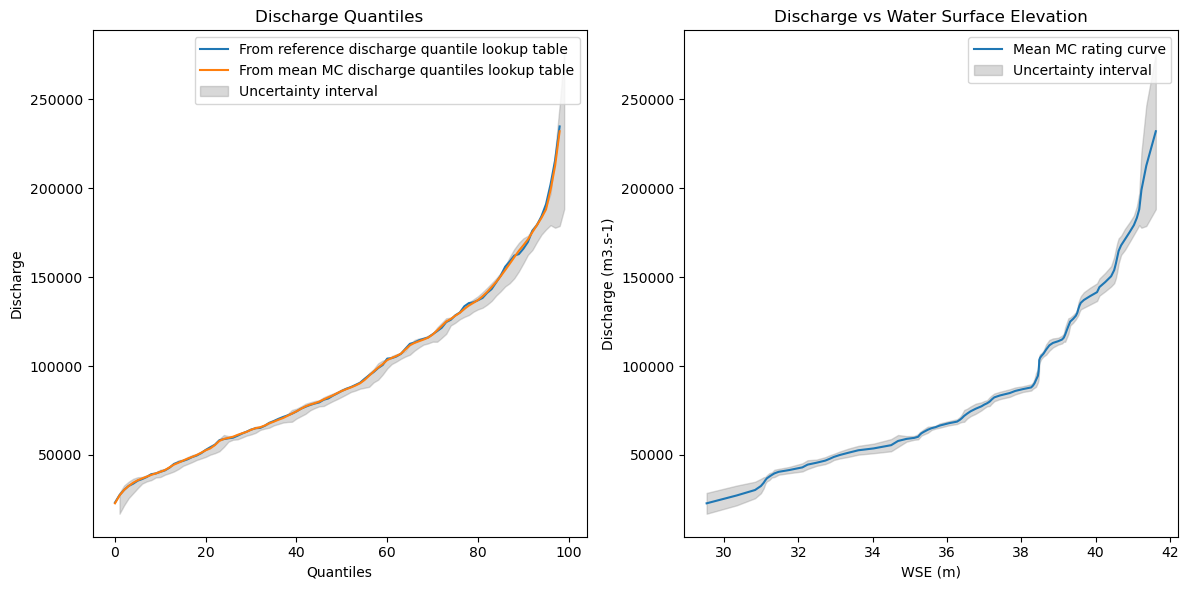

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.52 ; Corr: 0.64 ; NBIAS: 0.05 ; NSTDERR: 0.32 ; NRMSE: 0.34 ; PRMSE: 0.32 ; RRMSE: 0.34


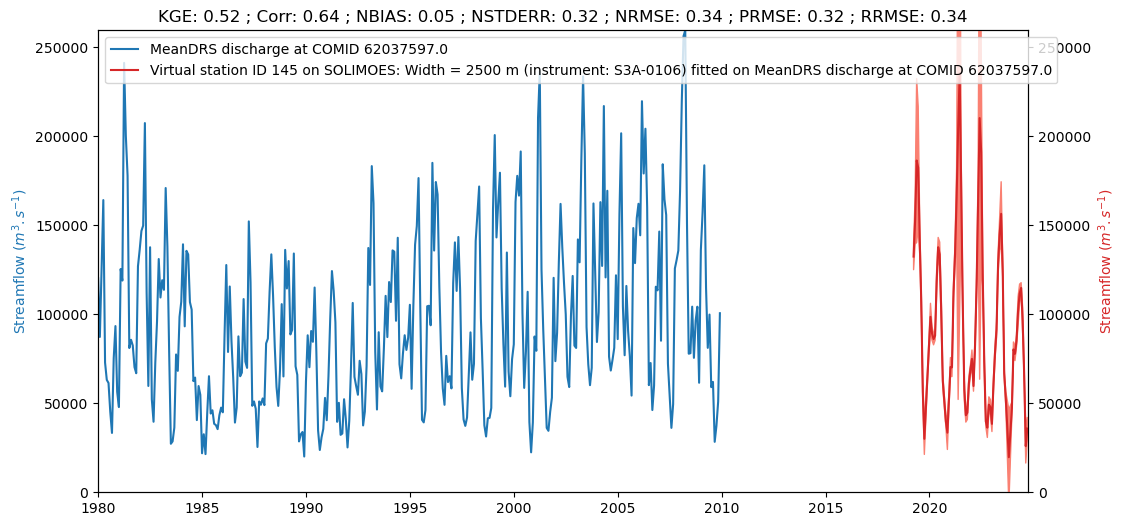

27110 ############################


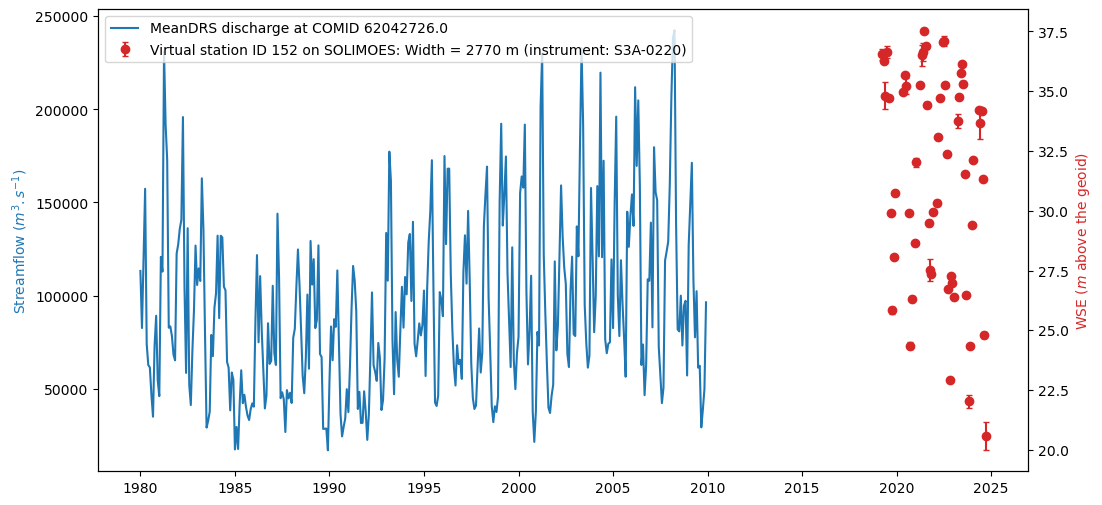

/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


1


/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/cerbelaud/anaconda3/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


2
3
4


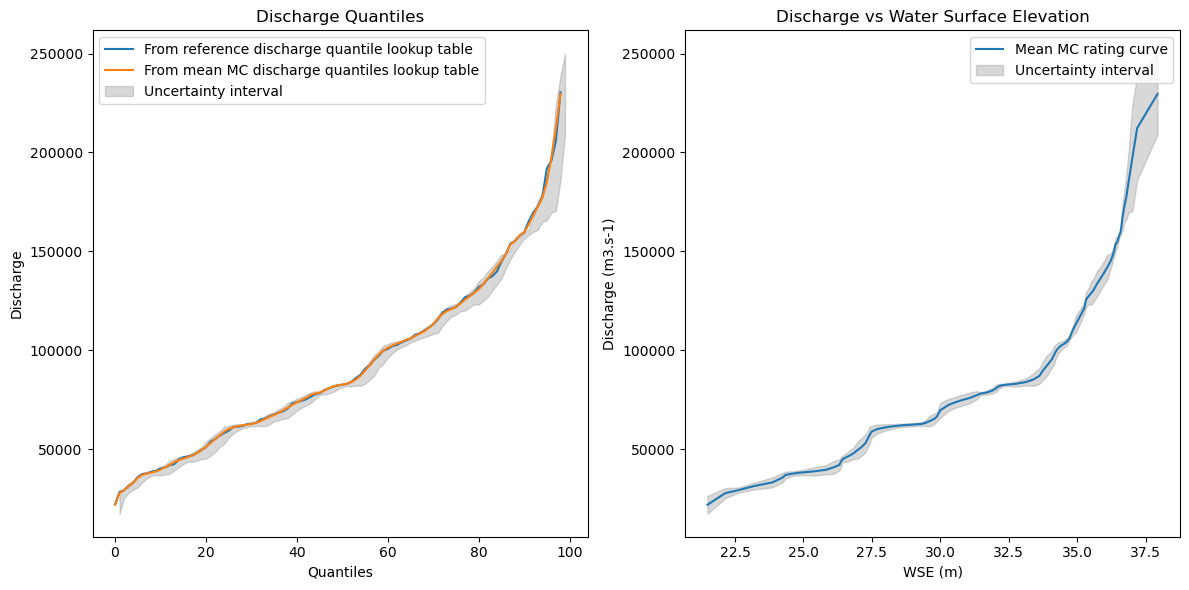

/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:225: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q = df1.resample('M').mean()
/var/folders/b1/jf1jt9ys40l147sxl2g3js9r0000gr/T/ipykernel_30721/1628651573.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()


KGE: 0.5 ; Corr: 0.6 ; NBIAS: 0.04 ; NSTDERR: 0.31 ; NRMSE: 0.33 ; PRMSE: 0.32 ; RRMSE: 0.35


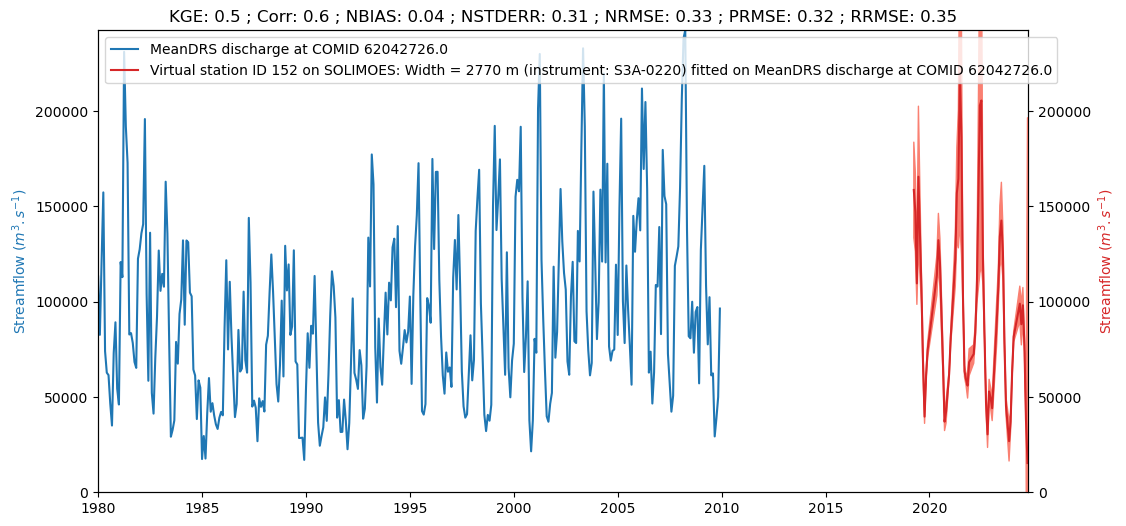

In [11]:
# **********************************************************************************************************************************
# Run the ARC NPQM discharge algorithm
# **********************************************************************************************************************************

for vs in vs_list:
    
    print(str(vs) + " ############################")
      
    
    # Model simulation at MERIT reach (dates are already in the same datetime format)
    # Get the ID (id of gauge, COMID of hydrographic network reach for a model etc.) where the VS was snapped to, i.e. where discharge is:
    rivid = alti_loc_data.loc[vs,ID_Q]
    # Filter the discharge dataset on that COMID for recent years: it is series s1
    s1 = ds_sims['Qout'].where((ds_sims.rivid == rivid) & (ds_sims.time.dt.year >= int(start_date[0:4])), drop = True).to_series()
    # Transforming it into a numpy series
    s1 = s1.reset_index(level=[1]).drop(columns = ['rivid'])['Qout']
    
    # VS WSE data is series 2 (s2), from start_wse to end_wse
    VS_ID = alti_loc_data.loc[vs,ID_VS]
    s2   = wse_data.loc[vs].iloc[start_wse:end_wse].dropna()
    s2_u = wse_u_data.loc[vs].iloc[start_wse:end_wse].dropna()
    # Convert the dates in column names to datetime format
    s2.index   = pd.to_datetime(s2.index)
    s2_u.index = pd.to_datetime(s2_u.index)
    
    # Concatenate the series
    df = pd.concat([s1,s2,s2_u], axis=1)
    df.columns = ['Qout', 'WSE', 'WSE_u']
    
    df1      = df['Qout'].loc[start_date:end_date].dropna()
    df2      = df['WSE'].loc[start_date:end_date].dropna()
    df2_u    = df['WSE_u'].loc[start_date:end_date].dropna()
    
    # Make sure wse and wse_u are at concurrent dates
    df2_u = df2_u[df2_u.index.isin(df2.index)]
    
    # If there are more than 10 years (120 months) of negative discharge data (MeanDRS), then do not run
    if len(np.where(df1<=0)[0])>120:
        print('Reach id with no data')
        continue
        
    ##########
    ### PLOT OF WSE (alti) AND Q (discharge) in time series
    ##########
    
    if do_plot_q_WSE == 1:
        # Create figure and axis objects
        fig, ax1 = plt.subplots(figsize=(12,6))
        plt.style.use('default')
        # Plot the first dataset on the primary y-axis
        ax1.plot(df1, color='tab:blue', label = type_discharge + ' discharge at ' + ID_Q + ' ' + str(rivid))
        ax1.set_ylabel('Streamflow ($m^3.s^{-1}$)', color='tab:blue')
        # Create a secondary y-axis and plot the second dataset
        ax2 = ax1.twinx()  # Create a twin Axes sharing the xaxis
        x      = df2.index
        y      = df2
        errors = df2_u
        try:
            # Hydrowebnext VS have name of river in column 1, width of river in column 4, 
            ax2.errorbar(x, y, yerr=errors, fmt='o', capsize=2, color='tab:red', label='Virtual station ID ' + str(VS_ID) + ' on ' + alti_loc_data.loc[vs][river_name_db] + ": Width = " + alti_loc_data.loc[vs][width_db] + " m (instrument: " + alti_loc_data.loc[vs][satvar] + ")")
        except:
            ax2.errorbar(x, y, yerr=errors, fmt='o', capsize=2, color='tab:red', label='Virtual station on: No info entered')
        ax2.set_ylabel('WSE ($m$ above the geoid)', color='tab:red')
        # Add legend
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        plt.show()
    
    
    ##########
    ### Quantile mapping
    ##########
    # 1. Remove WSE data points where the WSE uncertainty from the retracker is within X times the
    #    standard deviation of WSE data
    df2   = remove_uncertain_wse(df2, df2_u, threshold=1)
    # 2. Get WSE_u on the same dates
    df2_u = df2_u[df2_u.index.isin(df2.index)]
    # 3. Remove outliers in WSE
    scatter2 = remove_outliers(df2)
    scatter1 = df1
    
    # If there are two few points left after the removal of uncertain measurements
    if len(df2)<15:
        print('Dynamics are within uncertainty, no processing')
        continue
    
    
    #####################################
    # 4. Quantile mapping runs
    # Initial uncertainty around discharge
    df1_u = ( df1.clip(lower=0) - np.nanmin(df1.clip(lower=0)) ) * disch_uncer
    # Initial uncertainty around WSE: from the altimeter + a similar uncertainty to discharge for the Monte Carlo simulations
    df2_u = df2_u + ( df2.clip(lower=0) - np.nanmin(df2.clip(lower=0)) ) * wse_uncer + np.mean( df2.clip(lower=0)-np.nanmin(df2.clip(lower=0)) ) * wse_uncer
    # Running a first iteration of the algorithm
    quant_table_org, quant_look, quant_look_mean, quant_look_standard, discharge_recunst_mean, discharge_std, min_discharge_recunst, max_discharge_recunst, wse_prob, dis_prob, res_wse, res_dis, dis_perc_update, wse_perc_update = quantile_mapping(df1,df1_u,df2,df2_u)    
    # Keeping the residuals stored for the while statement
    res_wse_0 = res_wse
    res_dis_0 = res_dis
    # Initializing
    tempCount = 0
    iteration = 1
    # Loop until 3 sigma test on residues converges
    while tempCount==0:
        print(iteration)
        # Updating uncertainties from previous run
        df1_u = pd.Series(dis_perc_update[:, 1], index=df1_u.index).clip(lower=0)
        df2_u = pd.Series(wse_perc_update[:,1],  index=df2_u.index).clip(lower=0)
        # Running another iteration
        quant_table_org, quant_look, quant_look_mean, quant_look_standard, discharge_recunst_mean, discharge_std, min_discharge_recunst, max_discharge_recunst, wse_prob, dis_prob, res_wse, res_dis, dis_perc_update, wse_perc_update = quantile_mapping(df1,df1_u,df2,df2_u)    
        # If average residuals stop decreasing by more than 0.1 m for WSE, and more than 0.05 km3/day (around 500 m3/s), we reached enough accuracy
        if (np.abs((res_wse - res_wse_0)) < 0.1) & (np.abs((res_dis - res_dis_0)) < 0.05*10**9/24/3600):
            tempCount = 1
        else:
            res_wse_0 = res_wse
            res_dis_0 = res_dis
        # We stop after 5 iterations
        if iteration > 4:
            tempCount = 1
        iteration = iteration + 1
    
    if do_plot_QQ == 1:
        # Plot the mean MC Q quantiles with uncertainty
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        # Plot the mean MC discharge quantiles with uncertainty
        ax1.plot(quant_table_org[1:-1, 1], label='From reference discharge quantile lookup table')
        ax1.plot(quant_look_mean[1:-1,1], label='From mean MC discharge quantiles lookup table')
        ax1.fill_between(
            np.arange(1,100,1),               # X-axis values
            quant_look_mean[1:-1,1] - quant_look_standard[1:-1,1],            # Lower bound of the shaded area
            quant_look_mean[1:-1,1] + quant_look_standard[1:-1,1],            # Upper bound of the shaded area
            color='gray', alpha=0.3, label='Uncertainty interval'
        )
        ax1.legend()
        ax1.set_title('Discharge Quantiles')
        ax1.set_xlabel('Quantiles')
        ax1.set_ylabel('Discharge')

        # Plot the mean MC rating curve with uncertainty
        ax2.plot(quant_look_mean[1:-1,0], quant_look_mean[1:-1,1], label='Mean MC rating curve')
        ax2.fill_between(
            quant_look_mean[1:-1,0],                                    # X-axis values
            quant_look_mean[1:-1,1] - quant_look_standard[1:-1,1],       # Lower bound of the shaded area
            quant_look_mean[1:-1,1] + quant_look_standard[1:-1,1],       # Upper bound of the shaded area
            color='gray', alpha=0.3, label='Uncertainty interval'
        )
        ax2.legend()
        ax2.set_title('Discharge vs Water Surface Elevation')
        ax2.set_xlabel('WSE (m)')
        ax2.set_ylabel('Discharge (m3.s-1)')
        # Show the plots
        plt.tight_layout()
        plt.show()
    
    # Save the RC results
    for var in [f'WSE_{i}' for i in range(0, 101)]:
        alti_loc_data.loc[vs,var] = quant_table_org[int(var[4:7]),0]
    for var in [f'Q_{i}' for i in range(0, 101)]:
        alti_loc_data.loc[vs,var] = quant_table_org[int(var[2:5]),1]
    for var in [f'WSE_meanMC_{i}' for i in range(0, 101)]:
        alti_loc_data.loc[vs,var] = quant_look_mean[int(var[11:14]),0]
    for var in [f'Q_meanMC_{i}' for i in range(0, 101)]:
        alti_loc_data.loc[vs,var] = quant_look_mean[int(var[9:12]),1]
    for var in [f'Q_u_meanMC_{i}' for i in range(0, 101)]:
        alti_loc_data.loc[vs,var] = quant_look_standard[int(var[11:14]),1]
    
    # quant_table_org        contains the ordered reference lookup table: WSE quantiles in column 1, and the Q quantiles in column 2 FROM THE REFERENCE DATA
    # quant_look_mean        contains the ordered mean MC lookup table:   WSE quantiles in column 1, and the Q quantiles in column 2 FROM THE MEAN MC REALIZATIONS
    # quant_look_standard    contains the ordered uncertainty of MC lookup table:   WSE quantiles in column 1, and the Q quantiles in column 2 FROM THE STDDEV/RANGE of MC REALIZATIONS
    
    # discharge_recunst_mean is the time series of discharge produced from WSE by quantile mapping with mean MC realizations scenario
    # discharge_recunst      contains all the series of discharge produced from WSE via quantile mapping for all MC realizations
    # discharge_std          contains the variability of all the MC realizations of discharge produced from WSE via quantile mapping
    # dis_prob               contains the ORDERED percentiles for each date of WSE in column 1, the corresponding
    #                        quantiles from reference Q data in column 2, the quantiles from the mean of Q MC 
    #                        scenario in column 3, and the stddev/range of all Q MC scenarios in column 4
    #####################################

    ##########
    ### PLOT OF Q_RC_from_WSE + uncertainty vs Q_ref time series
    ##########
    if do_plot_qfromWSE == 1:
        
        # Create figure and axis objects
        fig, ax1 = plt.subplots(figsize=(12,6))
        # Plot the reference discharge on the primary y-axis
        ax1.plot(df1, color='tab:blue', label = type_discharge + ' discharge at ' + ID_Q + ' ' + str(rivid))
        ax1.set_ylabel('Streamflow ($m^3.s^{-1}$)', color='tab:blue')        
        
        # Create a secondary y-axis and plot the discharge from applying the RC to the WSE series
        ax2 = ax1.twinx()  # Create a twin Axes sharing the xaxis
        x  = df2.index
        y  = discharge_recunst_mean
        y1 = discharge_recunst_mean - discharge_std
        y2 = discharge_recunst_mean + discharge_std
        try:
            width_river = str(int(wse_data.loc[vs][width_db]))
        except:
            width_river = ''
        try:
            ax2.plot(x, y, color='tab:red', label='Virtual station ID ' + str(VS_ID) + ' on ' + wse_data.loc[vs][river_name_db] + ": Width = " + width_river + " m (instrument: " + wse_data.loc[vs][satvar] + ")" + ' fitted on ' + type_discharge + ' discharge at ' + ID_Q + ' ' + str(rivid))
        except:
            ax2.plot(x, y, color='tab:red', label='Virtual station on: No info entered')
        ax2.fill_between(x,y1.tolist(),y2.tolist(), color='salmon')
        ax2.set_ylabel('Streamflow ($m^3.s^{-1}$)', color='tab:red')
        # Add legend
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left')
        # Ensure both axes have the same y-max scale
        ax1.set_ylim(0, max(df1))
        ax2.set_ylim(0, max(df1))
        ax2.set_xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

    ##########
    ### Calculating interannual monthly mean aggregates to compare for evaluation metrics
    ##########
    
    ### Reference Q
    # Because MeanDRS data gives data every 30 days, hence for 01-01, then 01-31 etc., we need to rearrange
    # to have monthly means
    ###### TO REMOVE IF USING OTHER DATA TYPES
    df1.index = df1.index + pd.Timedelta(days=1)
    ###### TO REMOVE IF USING OTHER DATA TYPES
    monthly_means_Q = df1.resample('M').mean()
    Q = monthly_means_Q.groupby(monthly_means_Q.index.month).mean()    # 12 points for 12 months
    
    ### Q from WSE using the RC
    Q_from_WSE    = df2.copy()
    Q_from_WSE[:] = discharge_recunst_mean
    monthly_means_Q_from_WSE = Q_from_WSE.resample('M').mean()
    Q_RC = monthly_means_Q_from_WSE.groupby(monthly_means_Q_from_WSE.index.month).mean() # 12 points for 12 months

    # Calculate metrics on the 12 point series, see functions for definitions
    kge_     = np.round( kge(Q, Q_RC) ,2)
    try:
        corr_    = np.round( correlation(Q, Q_RC) ,2)
    except:
        corr_    = np.round( Q.corr(Q_RC), 2)
    nbias_   = np.round( nbias(Q, Q_RC) ,2)
    nstderr_ = np.round( nstderr(Q, Q_RC) ,2)
    nrmse_   = np.round( nrmse(Q, Q_RC) ,2)
    prmse_   = np.round( prmse(Q, Q_RC) ,2)
    rrmse_   = np.round( rrmse(Q, Q_RC) ,2)
    
    kge_list.append(kge_)
    corr_list.append(corr_)
    nbias_list.append(nbias_)
    nstderr_list.append(nstderr_)
    nrmse_list.append(nrmse_)
    prmse_list.append(prmse_)
    rrmse_list.append(rrmse_)
    
    # Writing in dataframes
    alti_loc_data.loc[vs,'KGE']     = kge_
    alti_loc_data.loc[vs,'Corr']    = corr_
    alti_loc_data.loc[vs,'NBIAS']   = nbias_
    alti_loc_data.loc[vs,'NSTDERR'] = nstderr_
    alti_loc_data.loc[vs,'NRMSE']   = nrmse_
    alti_loc_data.loc[vs,'PRMSE']   = prmse_
    alti_loc_data.loc[vs,'RRMSE']   = rrmse_
    print("KGE: "      + str(kge_) + 
                  " ; Corr: " + str(corr_) + 
                  " ; NBIAS: " + str(nbias_) +  
                  " ; NSTDERR: " + str(nstderr_) +
                  " ; NRMSE: " + str(nrmse_) +
                  " ; PRMSE: " + str(prmse_) +
                  " ; RRMSE: " + str(rrmse_)
                 )
          
    if do_plot_qfromWSE == 1:
        plt.title("KGE: "      + str(kge_) + 
                  " ; Corr: " + str(corr_) + 
                  " ; NBIAS: " + str(nbias_) +  
                  " ; NSTDERR: " + str(nstderr_) +
                  " ; NRMSE: " + str(nrmse_) +
                  " ; PRMSE: " + str(prmse_) +
                  " ; RRMSE: " + str(rrmse_)
                 )
        plt.show()

In [12]:
########
# Vizualize results
########

alti_loc_data[alti_loc_data['KGE']!=0]

,BASIN,RIVER,ID,TRIBUTARY OF,APPROX. WIDTH OF REACH (m),SURFACE OF UPSTREAM WATERSHED (km2),"RATING CURVE PARAMETERS A,b,Zo such that Q(m3/s) = A[H(m)-Zo]^b",REFERENCE ELLIPSOID,REFERENCE LONGITUDE,REFERENCE LATITUDE,...,Q_u_meanMC_98,Q_u_meanMC_99,Q_u_meanMC_100,KGE,Corr,NBIAS,NSTDERR,NRMSE,PRMSE,RRMSE
field_1,,,,,,,,,,,,,,,,,,,,,
726,AMAZONAS,SOLIMOES,148,NaN,1780,NaN,NA NA NA,WGS84,-67.0501,-2.6386,...,14465.014514,29619.317150,87519.219085,0.65,0.86,0.02,0.32,0.23,0.21,0.22
813,AMAZONAS,SOLIMOES,170,NaN,2650,NaN,NA NA NA,WGS84,-61.6401,-3.8384,...,14712.831869,8012.298853,0.000000,0.28,0.48,0.03,0.50,0.41,0.39,0.44
3436,AMAZONAS,SOLIMOES,180,NaN,1730,NaN,NA NA NA,WGS84,-64.2094,-3.6346,...,21653.381972,34885.309040,77389.647573,0.38,0.60,0.02,0.48,0.36,0.35,0.38
4515,AMAZONAS,SOLIMOES,166,NaN,2800,NaN,NA NA NA,WGS84,-69.5294,-4.1046,...,12939.720577,25291.893116,38059.686166,0.80,0.87,0.01,0.14,0.24,0.22,0.20
6202,AMAZONAS,SOLIMOES,192,NaN,2810,NaN,NA NA NA,WGS84,-61.4044,-3.6095,...,22046.172007,17537.789962,18674.468952,0.27,0.37,0.02,0.36,0.46,0.43,0.45
8082,AMAZONAS,SOLIMOES,189,NaN,2660,NaN,NA NA NA,WGS84,-62.3801,-3.8026,...,28113.678015,37537.661578,73366.956462,0.29,0.52,0.02,0.52,0.40,0.38,0.43
9968,AMAZONAS,SOLIMOES,161,NaN,1450,NaN,NA NA NA,WGS84,-69.4914,-4.2369,...,15011.554476,19172.121323,15408.089871,0.79,0.84,0.03,0.12,0.26,0.24,0.22
13125,AMAZONAS,SOLIMOES,195,NaN,2760,NaN,NA NA NA,WGS84,-66.8096,-2.6961,...,24832.893505,24680.897886,66068.690239,0.62,0.82,0.05,0.33,0.26,0.24,0.25
13723,AMAZONAS,SOLIMOES,193,NaN,2730,NaN,NA NA NA,WGS84,-69.2034,-3.4686,...,16062.471361,42128.597496,100422.764939,0.77,0.82,0.03,0.15,0.28,0.26,0.23


In [13]:
# Export results

alti_loc_data[alti_loc_data['KGE']!=0].to_csv(data_folder + '***/' + str(ID_list[0]) + '_' + str(ID_list[-1]) + '.csv')
                     

##
##
##
##
##
##
##